In [1]:
#pip install sciunit quantities efel scipy json2html neurom

In [2]:
#% matplotlib notebook
%matplotlib inline
from json2html import *
import quantities
from quantities import mV, nA
import IPython
import json
import collections
import pkg_resources
import numpy

#import sciunit
#from hippounit import models
from hippounit import tests
from hippounit.utils_50Ra_major_nmda import ModelLoader_synapse_on_Passive_Spine, ModelLoader_synapse_on_Active_Spine
from hippounit.utils_50Ra_major_nmda import ModelLoader_Modellke, ModelLoader_synapse_on_Existing_Spine
#from hippounit import capabilities
#import matplotlib.pyplot as plt

from neuron import h




Invalid MIT-MAGIC-COOKIE-1 key

In [3]:
import hippounit
print(hippounit.__file__)

/home/tarluca/Modellke_story/hippounit_Spine_project_20221102/hippounit/hippounit/__init__.py


# Synapses arrive at dendritic shaft - Active F-factor

## Instantiating the model

In [4]:
#all the outputs will be saved here. It will be an argument to the test.
"""Edit the line below"""
base_directory = '/mnt/csoport31-2/Modellezo_csapat/CA1_pyramidal/Spine_project_validation_results60/Basic_set_newopt/Shaft_active_F_factor_with_R_blocking/'

# path to mod files
"""Edit the line below"""
mod_files_path = "/home/tarluca/Modellke_story/Luca_modell_rework_2/prep_and_run_model_rework_new_K_stuff/nsg_csomag_model_rework_new/mod_files/"

# user function path
"""Edit the line below"""
user_function_path = '/home/tarluca/Modellke_story/Luca_modell_rework_2/prep_and_run_model_rework_new_K_stuff/nsg_csomag_model_rework_new/usr_fun_model_full_rework7.txt'

#Load cell model
model = ModelLoader_Modellke(mod_files_path = mod_files_path, user_function_path = user_function_path)

# path to hoc file
# the model must not display any GUI!!
"""Edit the line below"""
model.hocpath = "/home/tarluca/Modellke_story/Luca_modell_rework_2/prep_and_run_model_rework_new_K_stuff/nsg_csomag_model_rework_new/load_model_na_inhomo_minimal_model_full_soma_f_fact_true_diam_active_spine_KA_fact_50Ra.hoc"
# If the hoc file doesn't contain a template, this must be None (the default value is None)
model.template_name = None

# model.SomaSecList_name should be None, if there is no Section List in the model for the soma, or if the name of the soma section is given by setting model.soma (the default value is None)
model.SomaSecList_name = None
# if the soma is not in a section list or to use a specific somatic section, add its name here:
model.soma = 'soma'

# For the PSP Attenuation Test, and Back-propagating AP Test a section list containing the trunk sections is needed
model.TrunkSecList_name = 'trunk'
model.TuftSecList_name = 'tuft'
# For the Oblique Integration Test a section list containing the oblique dendritic sections is needed
model.ObliqueSecList_name = 'oblique_dendrites'

model.BasalSecList_name = 'basal_dendrites'

# It is important to set the v_init and the celsius parameters of the simulations here,
# as if they are only set in the model's files, they will be overwritten with the default values of the ModelLoader class.
# default values: v_init = -70, celsius = 34 
model.v_init = -70
model.celsius = 33

model.c_step_start = 0.000004
model.c_step_stop = 0.0000004
model.c_minmax = numpy.array([0.000004, 0.004])

## PSP Attenuation Test

In [5]:
# Load target data
"""Edit the line below"""
with open('/home/tarluca/Modellke_story/hippounit_Spine_project_20221102/hippounit/target_features/feat_PSP_attenuation_target_data.json') as f:
    observation = json.load(f, object_pairs_hook=collections.OrderedDict)

IPython.display.HTML(json2html.convert(json = observation))

mean_attenuation_soma/dend_100_um,0.67037891837
std_attenuation_soma/dend_100_um,0.0745536001493
mean_attenuation_soma/dend_200_um,0.485024302539
std_attenuation_soma/dend_200_um,0.108372269307
mean_attenuation_soma/dend_300_um,0.282118043034
std_attenuation_soma/dend_300_um,0.0482703550105


In [6]:
#stimuli
import pkg_resources
stim_file = pkg_resources.resource_filename("hippounit", "tests/stimuli/PSP_attenuation_stim/stim_PSP_attenuation_test.json")
with open(stim_file, 'r') as f:
    config = json.load(f, object_pairs_hook=collections.OrderedDict)

[-47.7233744163709, 0.011401720134011, 0.17866165872572, 0.110533546361937, 0.018195328014435, 4.13376819751696e-06, 0.558280689990683, -55.1977064419009, 0.000102007454842, 2.35151579716906, 0.00018773285843, 0.008177991377281, 0.082608363126436, 3.69975735209366, 0.00058114570326, 3.69310750687799, 5.1266274824495e-05, 1.15317561526235e-05, -25.8009959332103, 9.72470557972213, 9.75671751943343]
numprocs=1
Dendritic locations to be tested (with their actual distances): {('dendrite[31]', 0.5): 51.874440048986514, ('dendrite[117]', 0.5): 278.33171734906966, ('dendrite[77]', 0.5): 100.22118306272861, ('dendrite[99]', 0.5): 181.69452417270386, ('dendrite[95]', 0.5): 171.4537639215934, ('dendrite[105]', 0.5): 222.9376476900447, ('dendrite[87]', 0.5): 158.77871747375843, ('dendrite[91]', 0.5): 166.10161451767556, ('dendrite[102]', 0.5): 215.32249997419848, ('dendrite[129]', 0.5): 320.6552047153468, ('dendrite[101]', 0.5): 199.3211605489655, ('dendrite[103]', 0.5): 222.40356073341383, ('dend

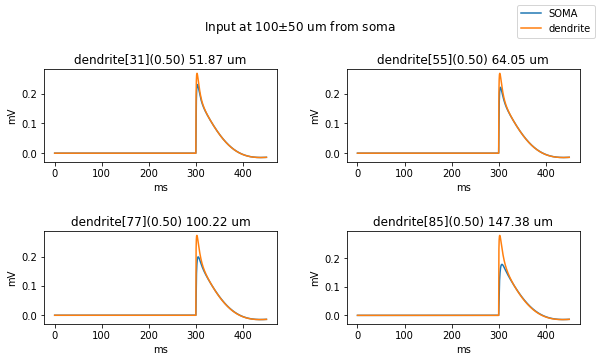

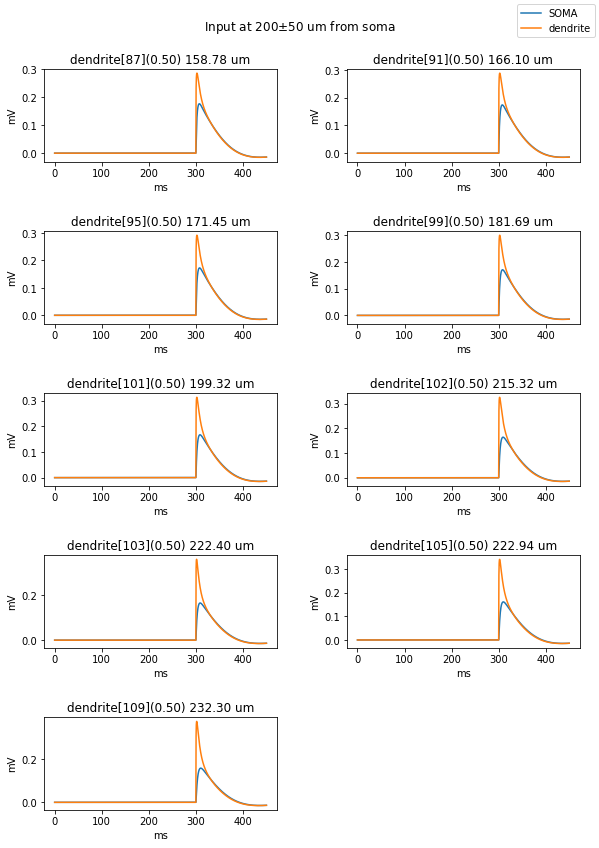

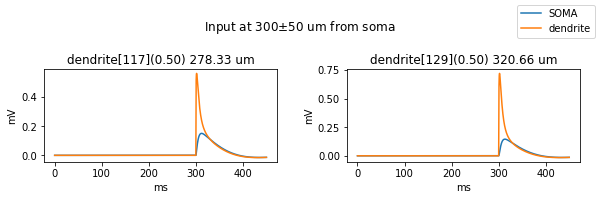

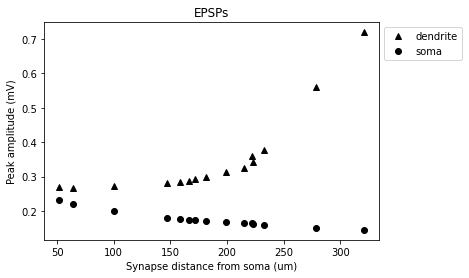

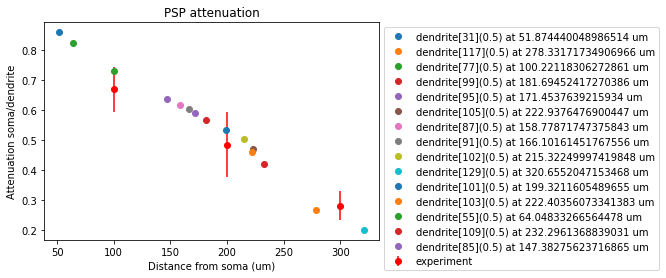

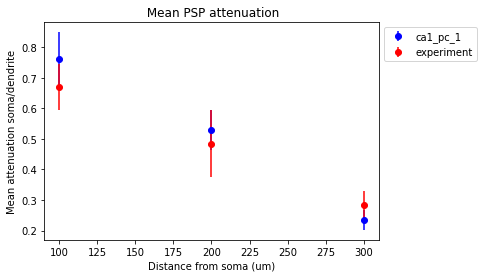

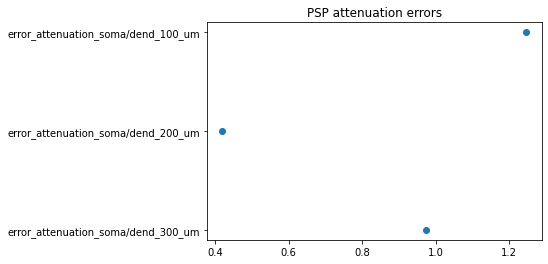

[-47.7233744163709, 0.0, 0.17866165872572, 0.110533546361937, 0.018195328014435, 4.13376819751696e-06, 0.558280689990683, -55.1977064419009, 0.000102007454842, 2.35151579716906, 0.00018773285843, 0.008177991377281, 0.082608363126436, 3.69975735209366, 0.00058114570326, 3.69310750687799, 5.1266274824495e-05, 1.15317561526235e-05, -25.8009959332103, 9.72470557972213, 9.75671751943343]
numprocs=1
Dendritic locations to be tested (with their actual distances): {('dendrite[31]', 0.5): 51.874440048986514, ('dendrite[117]', 0.5): 278.33171734906966, ('dendrite[77]', 0.5): 100.22118306272861, ('dendrite[99]', 0.5): 181.69452417270386, ('dendrite[95]', 0.5): 171.4537639215934, ('dendrite[105]', 0.5): 222.9376476900447, ('dendrite[87]', 0.5): 158.77871747375843, ('dendrite[91]', 0.5): 166.10161451767556, ('dendrite[102]', 0.5): 215.32249997419848, ('dendrite[129]', 0.5): 320.6552047153468, ('dendrite[101]', 0.5): 199.3211605489655, ('dendrite[103]', 0.5): 222.40356073341383, ('dendrite[55]', 0.5

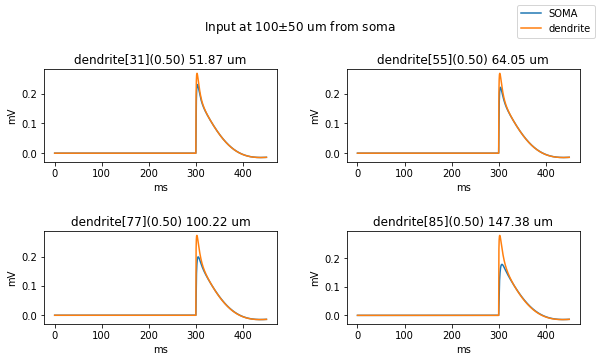

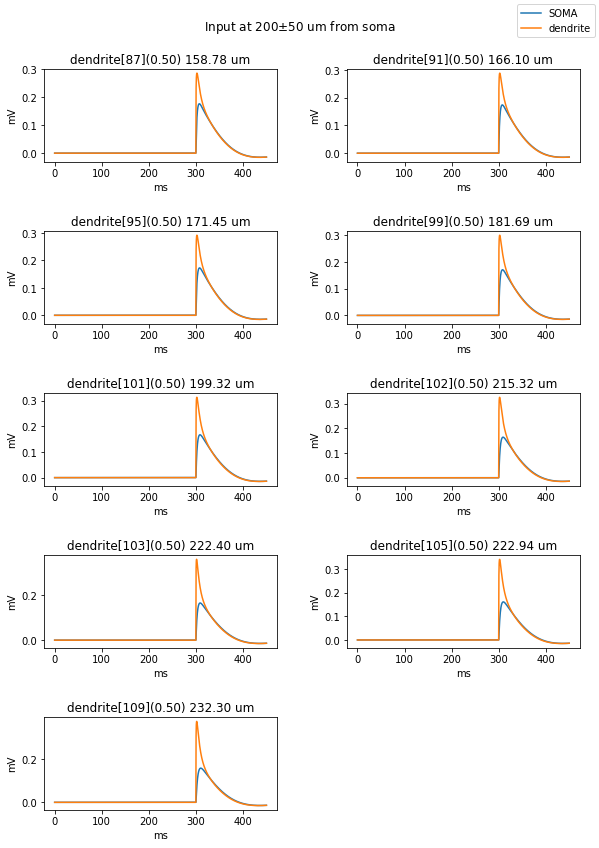

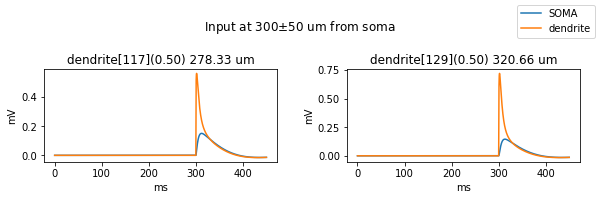

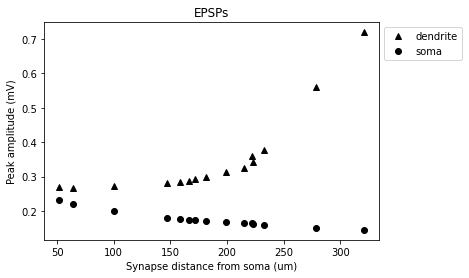

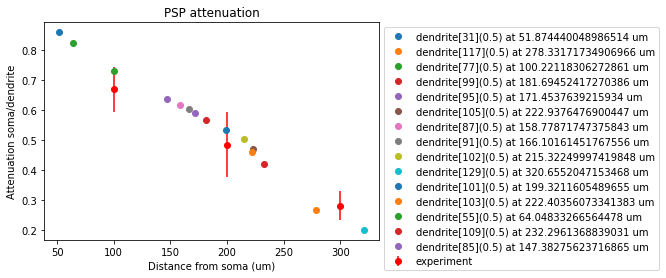

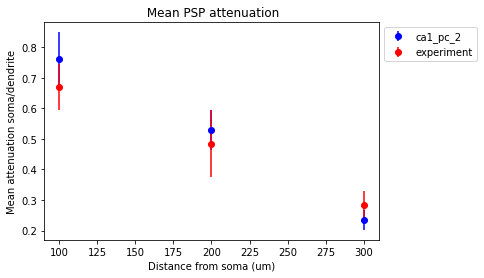

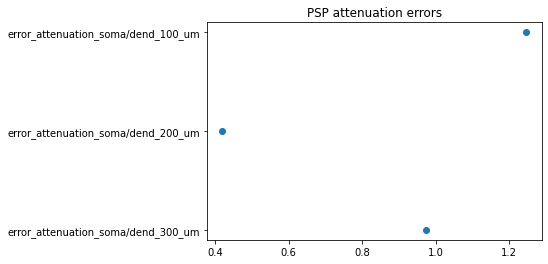

[-47.7233744163709, 0.011401720134011, 0.0, 0.110533546361937, 0.018195328014435, 4.13376819751696e-06, 0.558280689990683, -55.1977064419009, 0.000102007454842, 2.35151579716906, 0.00018773285843, 0.008177991377281, 0.082608363126436, 3.69975735209366, 0.00058114570326, 3.69310750687799, 5.1266274824495e-05, 1.15317561526235e-05, -25.8009959332103, 9.72470557972213, 9.75671751943343]
numprocs=1
Dendritic locations to be tested (with their actual distances): {('dendrite[31]', 0.5): 51.874440048986514, ('dendrite[117]', 0.5): 278.33171734906966, ('dendrite[77]', 0.5): 100.22118306272861, ('dendrite[99]', 0.5): 181.69452417270386, ('dendrite[95]', 0.5): 171.4537639215934, ('dendrite[105]', 0.5): 222.9376476900447, ('dendrite[87]', 0.5): 158.77871747375843, ('dendrite[91]', 0.5): 166.10161451767556, ('dendrite[102]', 0.5): 215.32249997419848, ('dendrite[129]', 0.5): 320.6552047153468, ('dendrite[101]', 0.5): 199.3211605489655, ('dendrite[103]', 0.5): 222.40356073341383, ('dendrite[55]', 0.

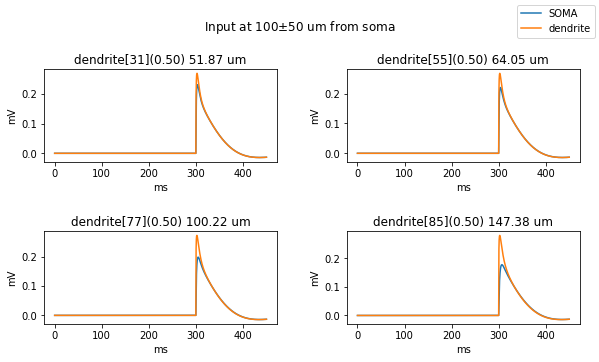

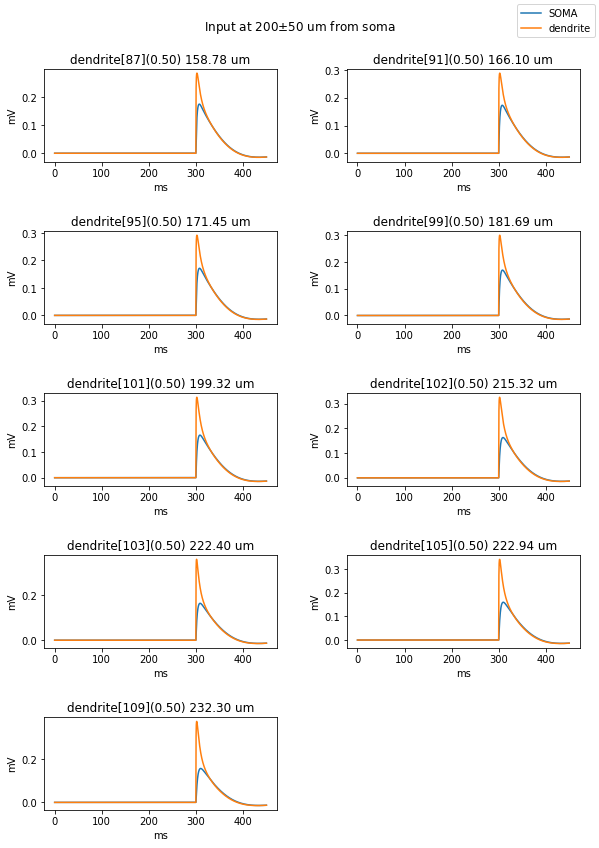

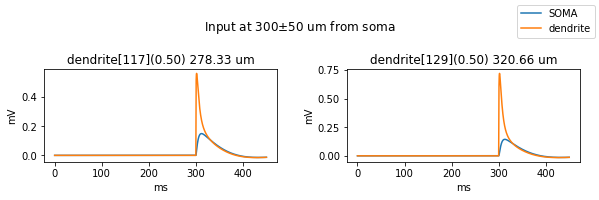

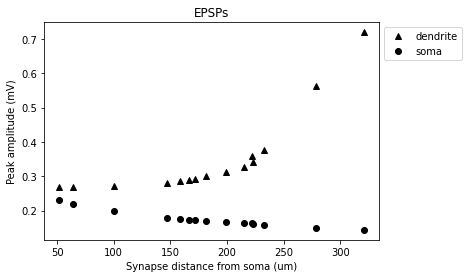

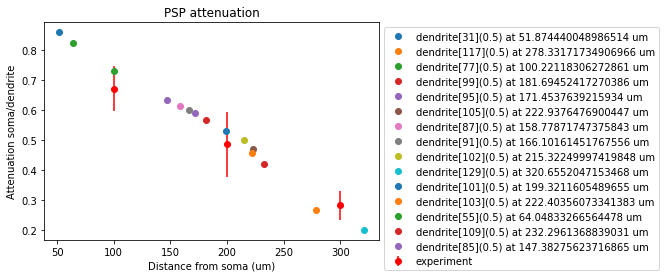

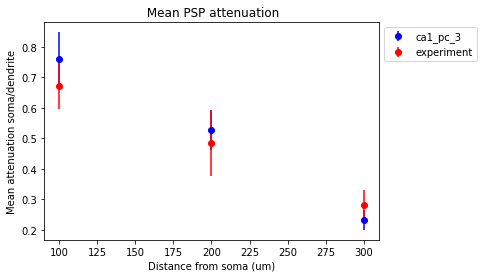

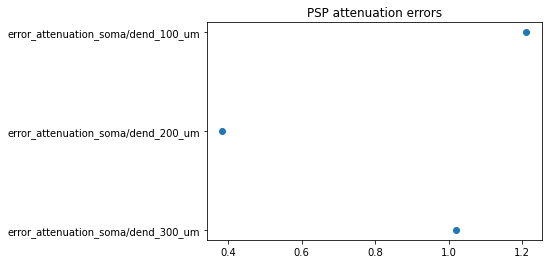

[-47.7233744163709, 0.011401720134011, 0.17866165872572, 0.0, 0.018195328014435, 4.13376819751696e-06, 0.558280689990683, -55.1977064419009, 0.000102007454842, 2.35151579716906, 0.00018773285843, 0.008177991377281, 0.082608363126436, 3.69975735209366, 0.00058114570326, 3.69310750687799, 5.1266274824495e-05, 1.15317561526235e-05, -25.8009959332103, 9.72470557972213, 9.75671751943343]
numprocs=1
Dendritic locations to be tested (with their actual distances): {('dendrite[31]', 0.5): 51.874440048986514, ('dendrite[117]', 0.5): 278.33171734906966, ('dendrite[77]', 0.5): 100.22118306272861, ('dendrite[99]', 0.5): 181.69452417270386, ('dendrite[95]', 0.5): 171.4537639215934, ('dendrite[105]', 0.5): 222.9376476900447, ('dendrite[87]', 0.5): 158.77871747375843, ('dendrite[91]', 0.5): 166.10161451767556, ('dendrite[102]', 0.5): 215.32249997419848, ('dendrite[129]', 0.5): 320.6552047153468, ('dendrite[101]', 0.5): 199.3211605489655, ('dendrite[103]', 0.5): 222.40356073341383, ('dendrite[55]', 0.5

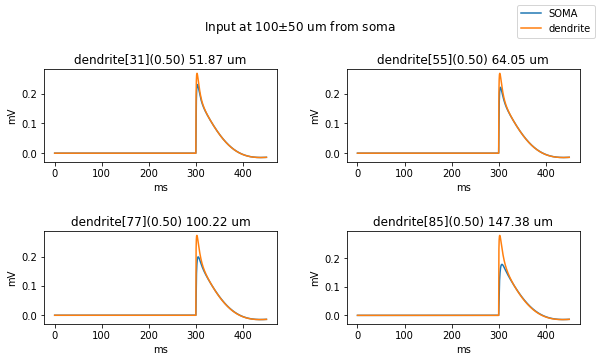

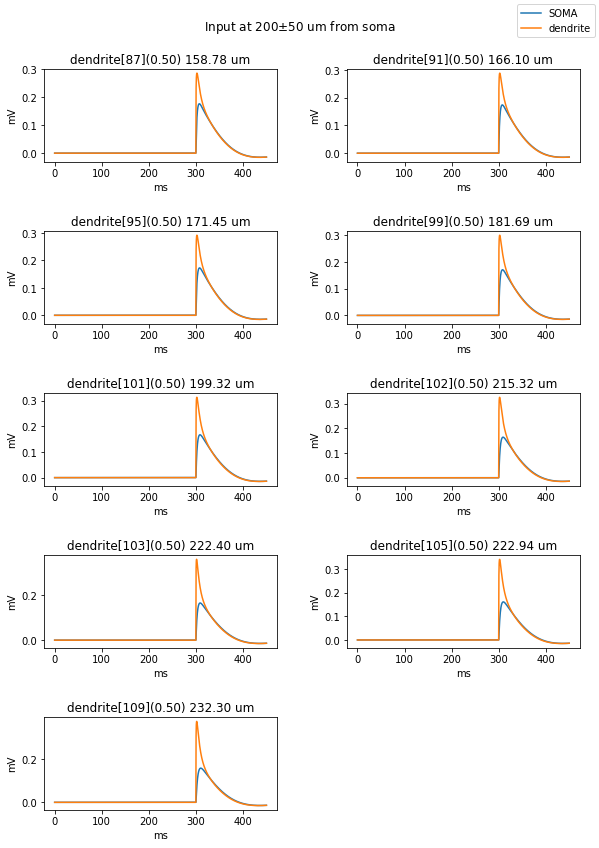

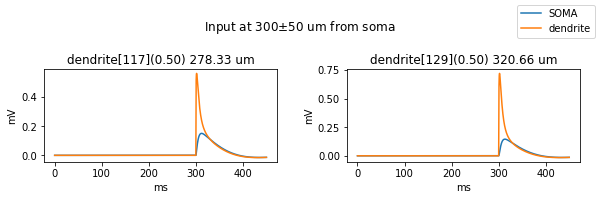

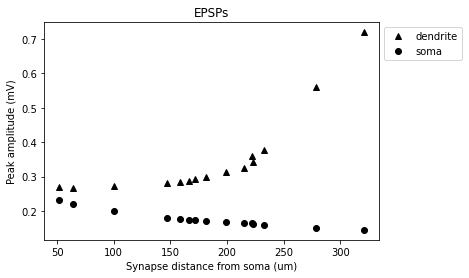

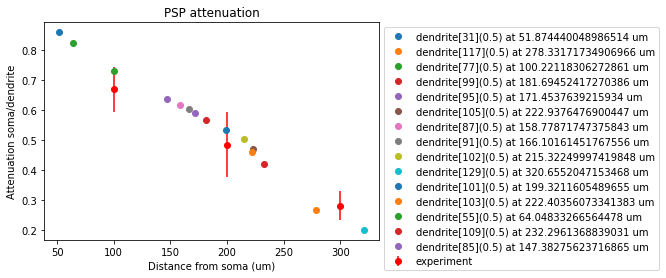

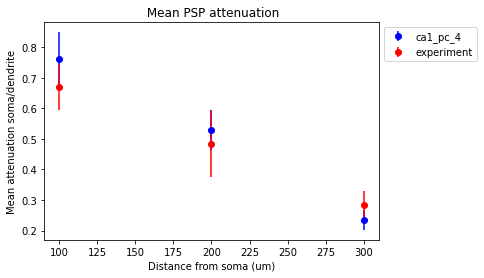

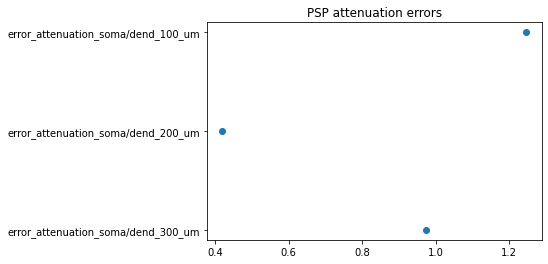

[-47.7233744163709, 0.0, 0.17866165872572, 0.0, 0.018195328014435, 4.13376819751696e-06, 0.558280689990683, -55.1977064419009, 0.000102007454842, 2.35151579716906, 0.00018773285843, 0.008177991377281, 0.082608363126436, 3.69975735209366, 0.00058114570326, 3.69310750687799, 5.1266274824495e-05, 1.15317561526235e-05, -25.8009959332103, 9.72470557972213, 9.75671751943343]
numprocs=1
Dendritic locations to be tested (with their actual distances): {('dendrite[31]', 0.5): 51.874440048986514, ('dendrite[117]', 0.5): 278.33171734906966, ('dendrite[77]', 0.5): 100.22118306272861, ('dendrite[99]', 0.5): 181.69452417270386, ('dendrite[95]', 0.5): 171.4537639215934, ('dendrite[105]', 0.5): 222.9376476900447, ('dendrite[87]', 0.5): 158.77871747375843, ('dendrite[91]', 0.5): 166.10161451767556, ('dendrite[102]', 0.5): 215.32249997419848, ('dendrite[129]', 0.5): 320.6552047153468, ('dendrite[101]', 0.5): 199.3211605489655, ('dendrite[103]', 0.5): 222.40356073341383, ('dendrite[55]', 0.5): 64.04833266

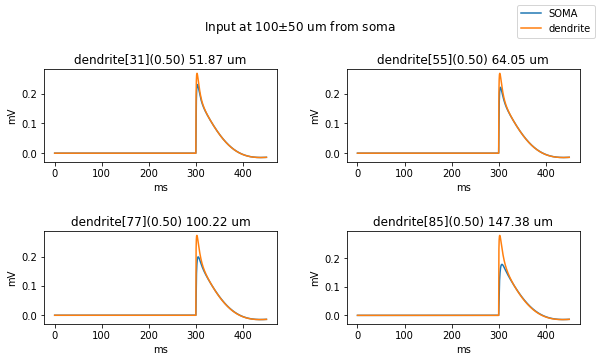

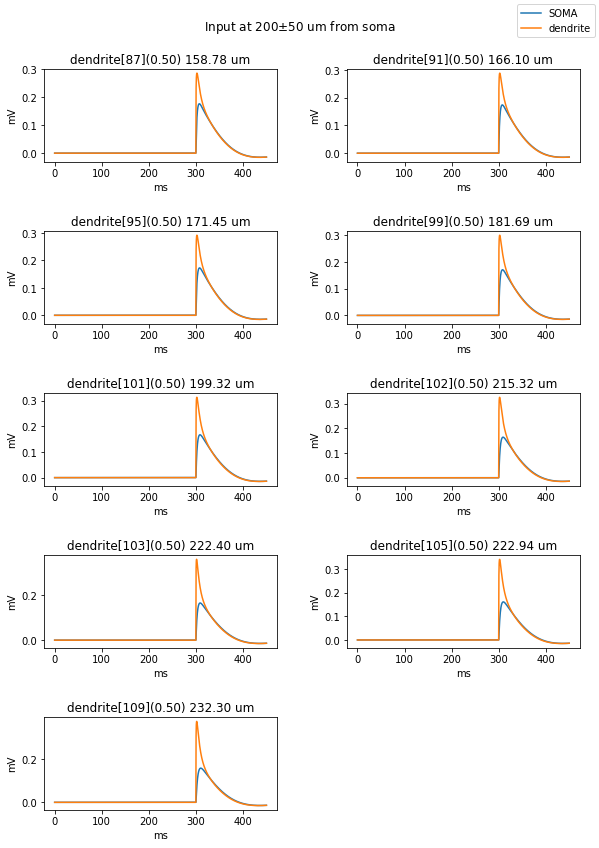

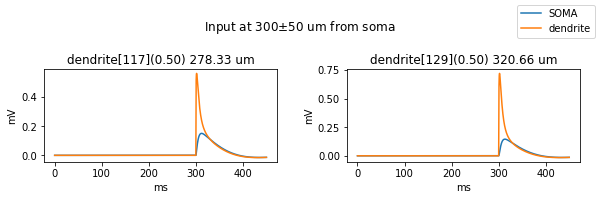

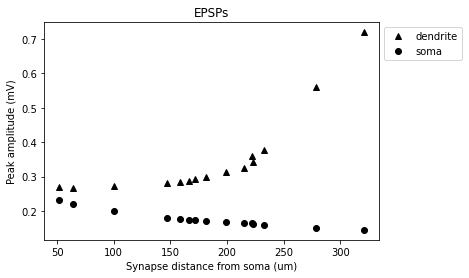

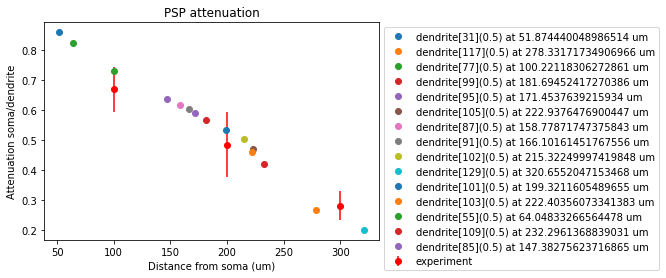

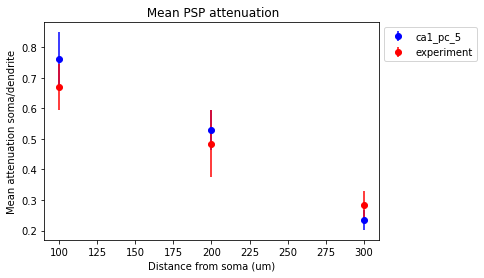

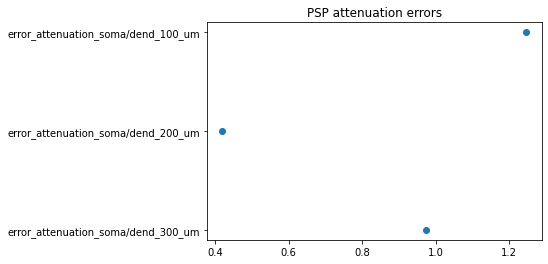

[-47.7233744163709, 0.011401720134011, 0.17866165872572, 0.110533546361937, 0.0, 4.13376819751696e-06, 0.558280689990683, -55.1977064419009, 0.000102007454842, 2.35151579716906, 0.00018773285843, 0.008177991377281, 0.082608363126436, 3.69975735209366, 0.00058114570326, 3.69310750687799, 5.1266274824495e-05, 1.15317561526235e-05, -25.8009959332103, 9.72470557972213, 9.75671751943343]
numprocs=1
Dendritic locations to be tested (with their actual distances): {('dendrite[31]', 0.5): 51.874440048986514, ('dendrite[117]', 0.5): 278.33171734906966, ('dendrite[77]', 0.5): 100.22118306272861, ('dendrite[99]', 0.5): 181.69452417270386, ('dendrite[95]', 0.5): 171.4537639215934, ('dendrite[105]', 0.5): 222.9376476900447, ('dendrite[87]', 0.5): 158.77871747375843, ('dendrite[91]', 0.5): 166.10161451767556, ('dendrite[102]', 0.5): 215.32249997419848, ('dendrite[129]', 0.5): 320.6552047153468, ('dendrite[101]', 0.5): 199.3211605489655, ('dendrite[103]', 0.5): 222.40356073341383, ('dendrite[55]', 0.5

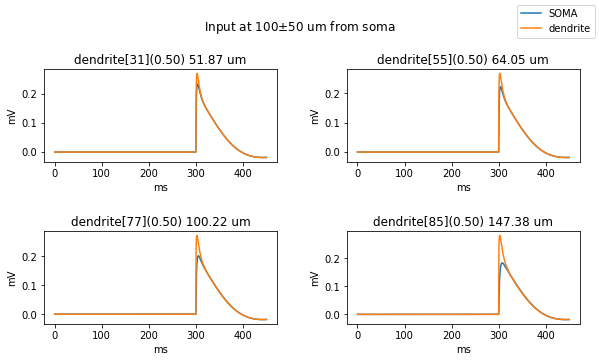

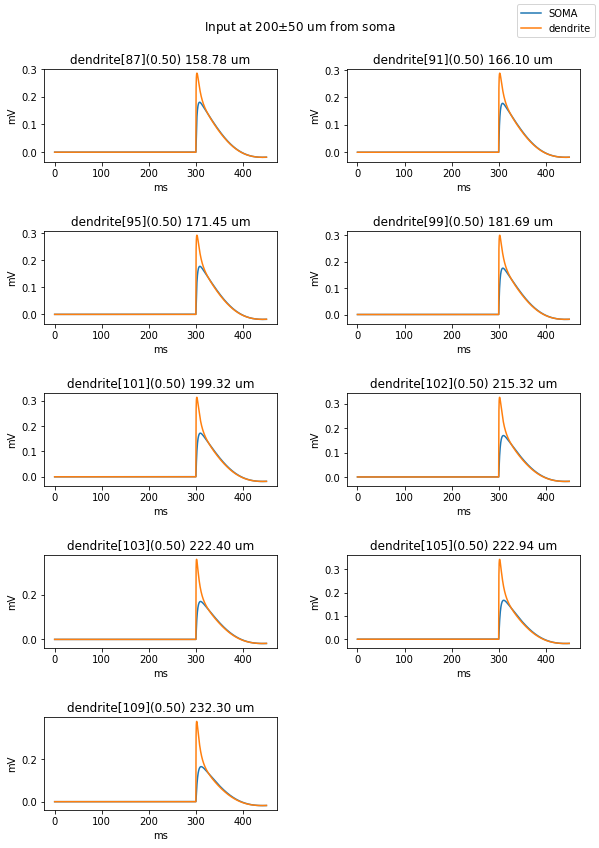

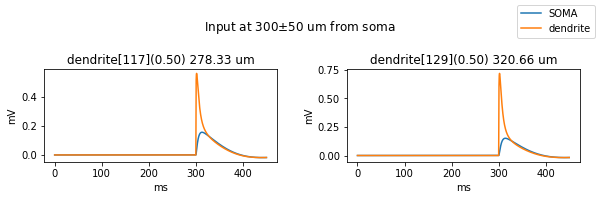

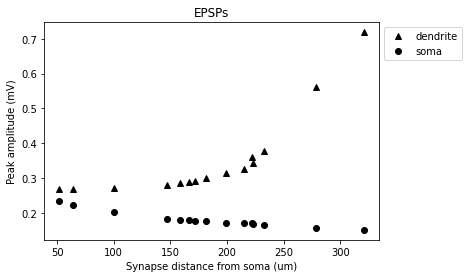

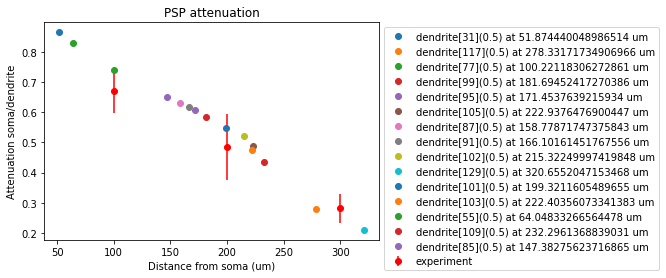

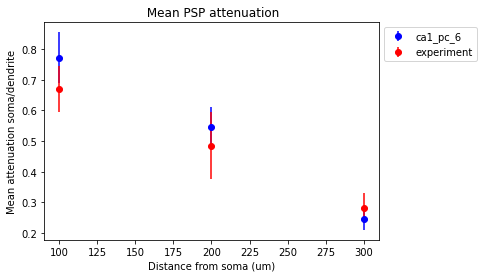

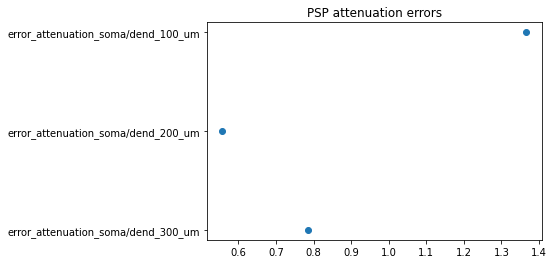

[-47.7233744163709, 0.011401720134011, 0.17866165872572, 0.110533546361937, 0.018195328014435, 4.13376819751696e-06, 0.0, -55.1977064419009, 0.000102007454842, 2.35151579716906, 0.00018773285843, 0.008177991377281, 0.082608363126436, 3.69975735209366, 0.00058114570326, 3.69310750687799, 5.1266274824495e-05, 1.15317561526235e-05, -25.8009959332103, 9.72470557972213, 9.75671751943343]
numprocs=1
Dendritic locations to be tested (with their actual distances): {('dendrite[31]', 0.5): 51.874440048986514, ('dendrite[117]', 0.5): 278.33171734906966, ('dendrite[77]', 0.5): 100.22118306272861, ('dendrite[99]', 0.5): 181.69452417270386, ('dendrite[95]', 0.5): 171.4537639215934, ('dendrite[105]', 0.5): 222.9376476900447, ('dendrite[87]', 0.5): 158.77871747375843, ('dendrite[91]', 0.5): 166.10161451767556, ('dendrite[102]', 0.5): 215.32249997419848, ('dendrite[129]', 0.5): 320.6552047153468, ('dendrite[101]', 0.5): 199.3211605489655, ('dendrite[103]', 0.5): 222.40356073341383, ('dendrite[55]', 0.5

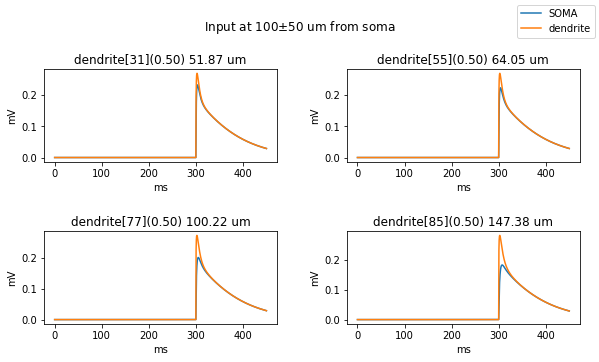

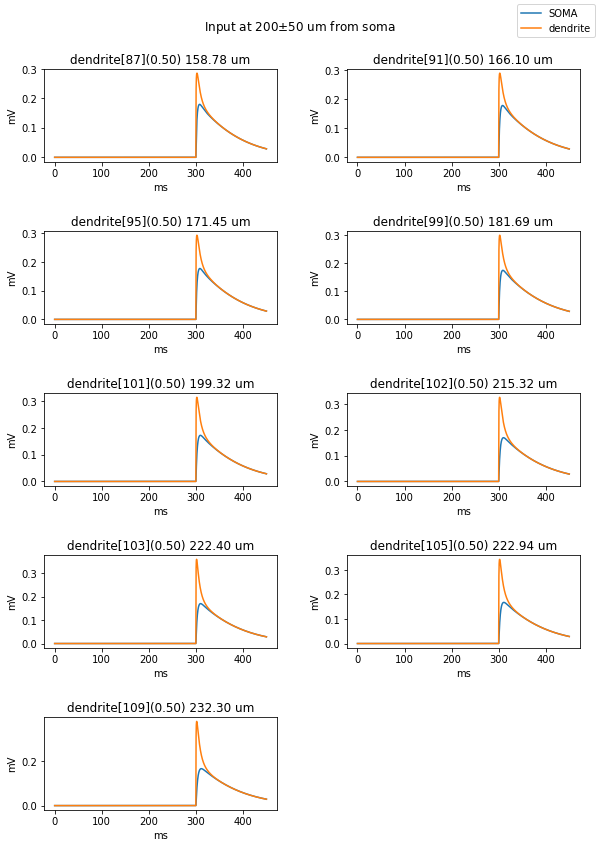

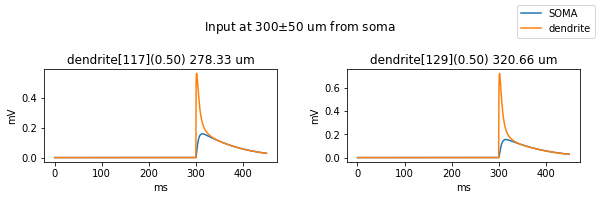

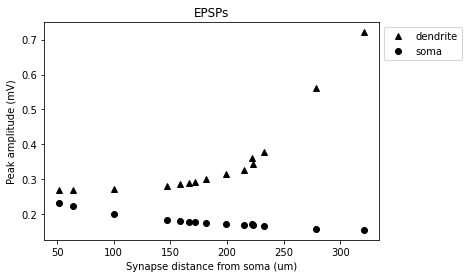

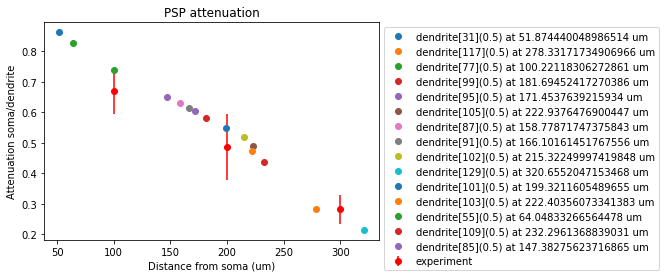

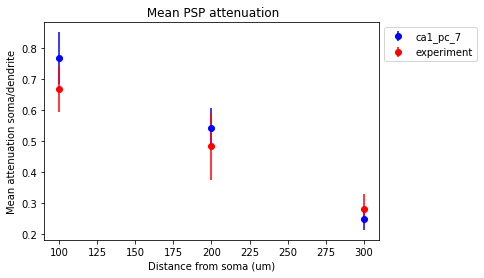

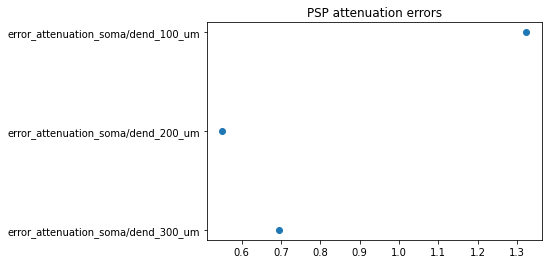

[-47.7233744163709, 0.011401720134011, 0.17866165872572, 0.110533546361937, 0.018195328014435, 4.13376819751696e-06, 0.558280689990683, -55.1977064419009, 0.0, 2.35151579716906, 0.00018773285843, 0.008177991377281, 0.082608363126436, 3.69975735209366, 0.00058114570326, 3.69310750687799, 5.1266274824495e-05, 1.15317561526235e-05, -25.8009959332103, 9.72470557972213, 9.75671751943343]
numprocs=1
Dendritic locations to be tested (with their actual distances): {('dendrite[31]', 0.5): 51.874440048986514, ('dendrite[117]', 0.5): 278.33171734906966, ('dendrite[77]', 0.5): 100.22118306272861, ('dendrite[99]', 0.5): 181.69452417270386, ('dendrite[95]', 0.5): 171.4537639215934, ('dendrite[105]', 0.5): 222.9376476900447, ('dendrite[87]', 0.5): 158.77871747375843, ('dendrite[91]', 0.5): 166.10161451767556, ('dendrite[102]', 0.5): 215.32249997419848, ('dendrite[129]', 0.5): 320.6552047153468, ('dendrite[101]', 0.5): 199.3211605489655, ('dendrite[103]', 0.5): 222.40356073341383, ('dendrite[55]', 0.5

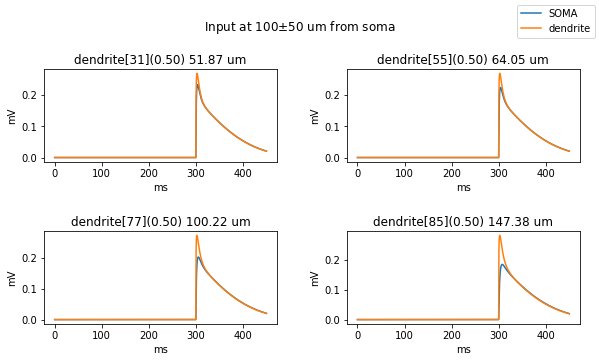

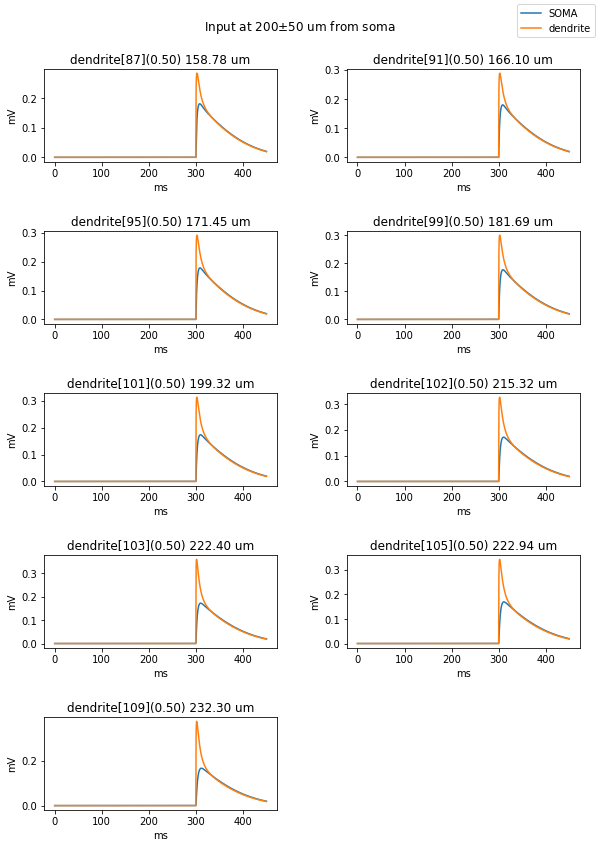

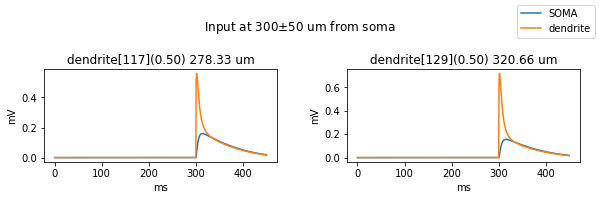

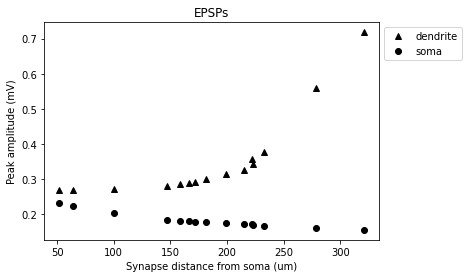

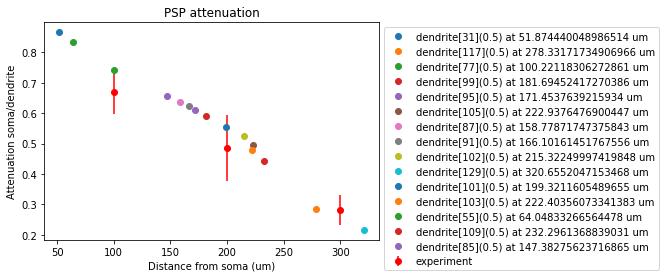

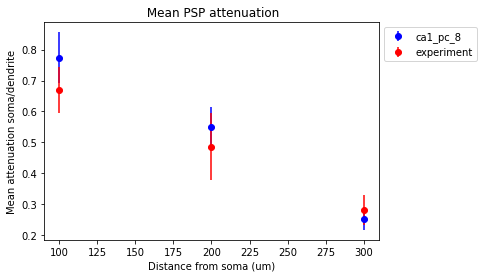

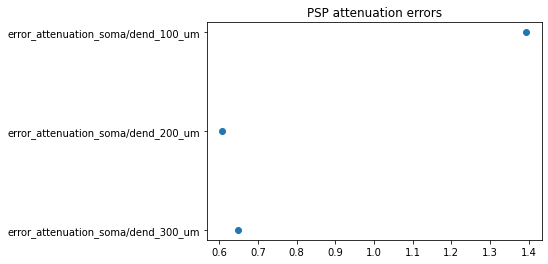

[-47.7233744163709, 0.011401720134011, 0.17866165872572, 0.110533546361937, 0.018195328014435, 4.13376819751696e-06, 0.558280689990683, -55.1977064419009, 0.000102007454842, 0.0, 0.00018773285843, 0.008177991377281, 0.082608363126436, 3.69975735209366, 0.00058114570326, 3.69310750687799, 5.1266274824495e-05, 1.15317561526235e-05, -25.8009959332103, 9.72470557972213, 9.75671751943343]
numprocs=1
Dendritic locations to be tested (with their actual distances): {('dendrite[31]', 0.5): 51.874440048986514, ('dendrite[117]', 0.5): 278.33171734906966, ('dendrite[77]', 0.5): 100.22118306272861, ('dendrite[99]', 0.5): 181.69452417270386, ('dendrite[95]', 0.5): 171.4537639215934, ('dendrite[105]', 0.5): 222.9376476900447, ('dendrite[87]', 0.5): 158.77871747375843, ('dendrite[91]', 0.5): 166.10161451767556, ('dendrite[102]', 0.5): 215.32249997419848, ('dendrite[129]', 0.5): 320.6552047153468, ('dendrite[101]', 0.5): 199.3211605489655, ('dendrite[103]', 0.5): 222.40356073341383, ('dendrite[55]', 0.

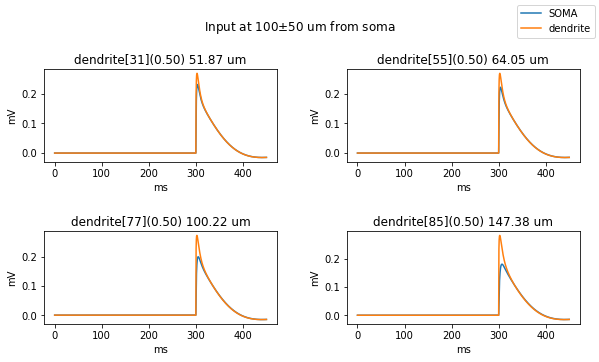

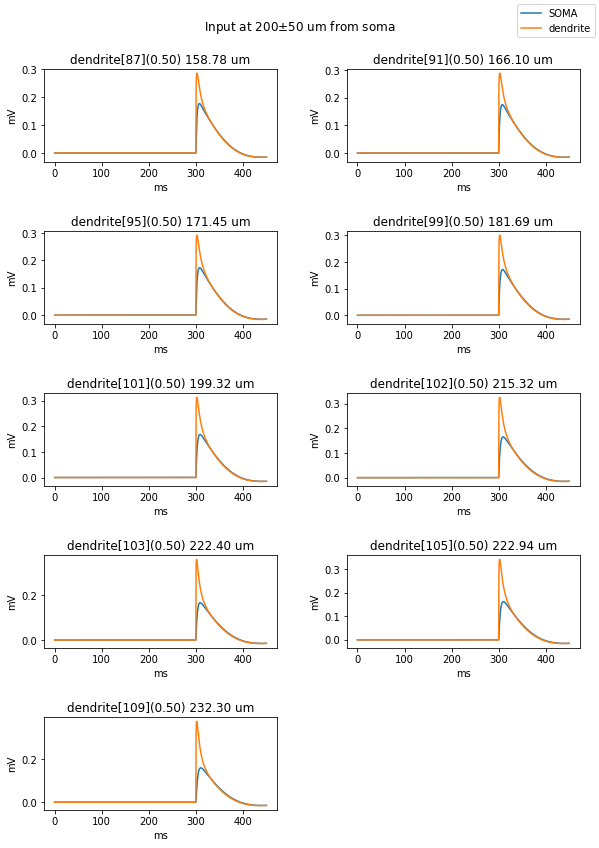

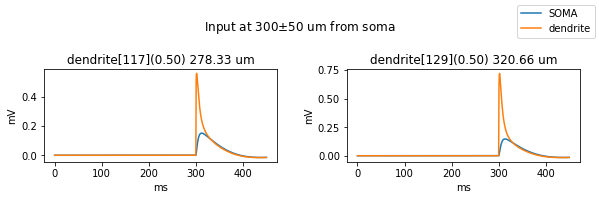

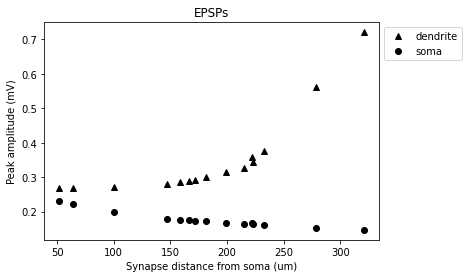

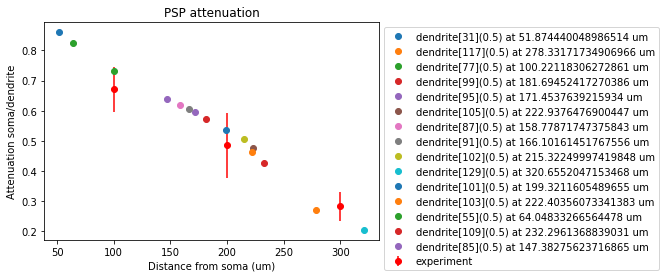

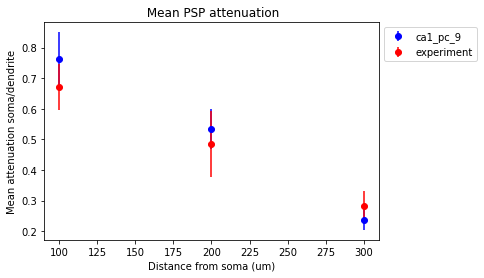

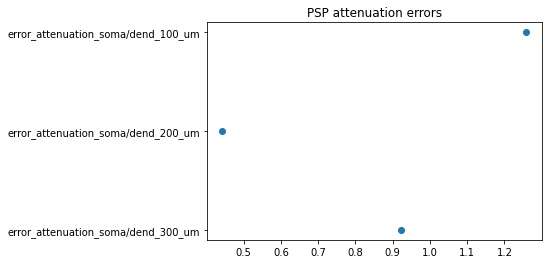

[-47.7233744163709, 0.011401720134011, 0.17866165872572, 0.110533546361937, 0.018195328014435, 4.13376819751696e-06, 0.558280689990683, -55.1977064419009, 0.000102007454842, 2.35151579716906, 0.0, 0.008177991377281, 0.082608363126436, 3.69975735209366, 0.00058114570326, 3.69310750687799, 5.1266274824495e-05, 1.15317561526235e-05, -25.8009959332103, 9.72470557972213, 9.75671751943343]
numprocs=1
Dendritic locations to be tested (with their actual distances): {('dendrite[31]', 0.5): 51.874440048986514, ('dendrite[117]', 0.5): 278.33171734906966, ('dendrite[77]', 0.5): 100.22118306272861, ('dendrite[99]', 0.5): 181.69452417270386, ('dendrite[95]', 0.5): 171.4537639215934, ('dendrite[105]', 0.5): 222.9376476900447, ('dendrite[87]', 0.5): 158.77871747375843, ('dendrite[91]', 0.5): 166.10161451767556, ('dendrite[102]', 0.5): 215.32249997419848, ('dendrite[129]', 0.5): 320.6552047153468, ('dendrite[101]', 0.5): 199.3211605489655, ('dendrite[103]', 0.5): 222.40356073341383, ('dendrite[55]', 0.

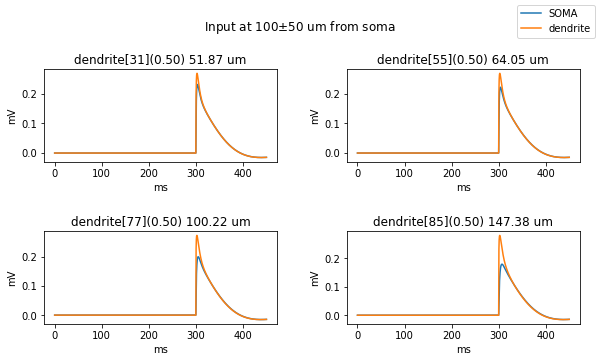

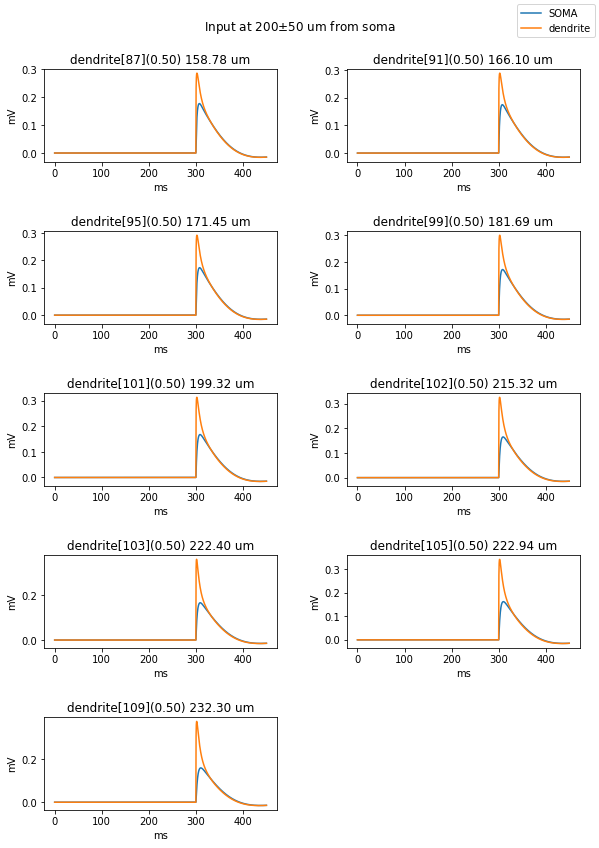

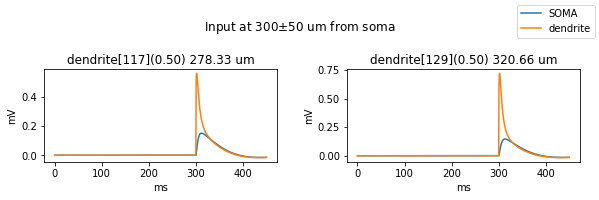

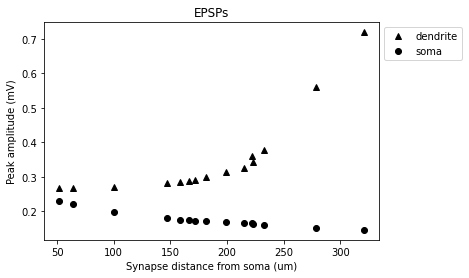

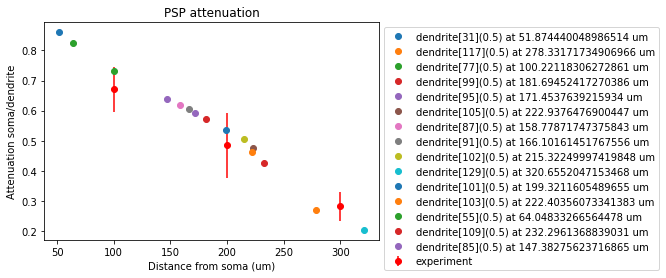

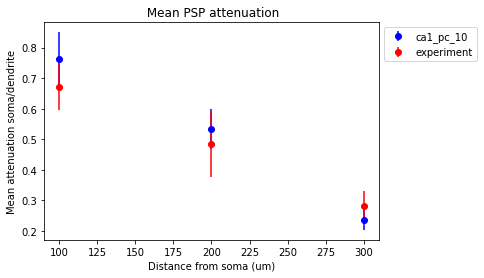

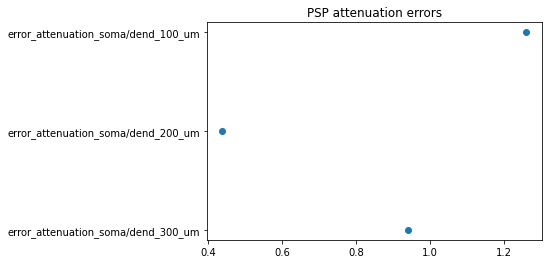

[-47.7233744163709, 0.011401720134011, 0.17866165872572, 0.110533546361937, 0.0, 4.13376819751696e-06, 0.558280689990683, -55.1977064419009, 0.000102007454842, 2.35151579716906, 0.0, 0.008177991377281, 0.082608363126436, 3.69975735209366, 0.00058114570326, 3.69310750687799, 5.1266274824495e-05, 1.15317561526235e-05, -25.8009959332103, 9.72470557972213, 9.75671751943343]
numprocs=1
Dendritic locations to be tested (with their actual distances): {('dendrite[31]', 0.5): 51.874440048986514, ('dendrite[117]', 0.5): 278.33171734906966, ('dendrite[77]', 0.5): 100.22118306272861, ('dendrite[99]', 0.5): 181.69452417270386, ('dendrite[95]', 0.5): 171.4537639215934, ('dendrite[105]', 0.5): 222.9376476900447, ('dendrite[87]', 0.5): 158.77871747375843, ('dendrite[91]', 0.5): 166.10161451767556, ('dendrite[102]', 0.5): 215.32249997419848, ('dendrite[129]', 0.5): 320.6552047153468, ('dendrite[101]', 0.5): 199.3211605489655, ('dendrite[103]', 0.5): 222.40356073341383, ('dendrite[55]', 0.5): 64.0483326

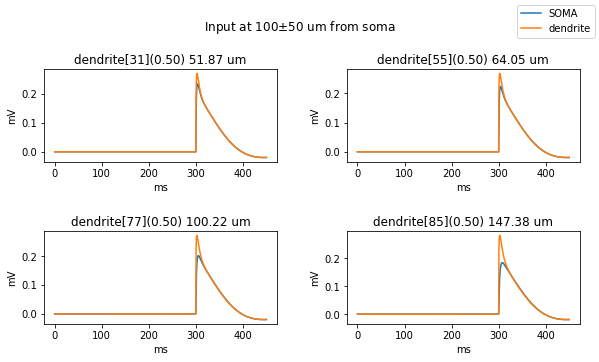

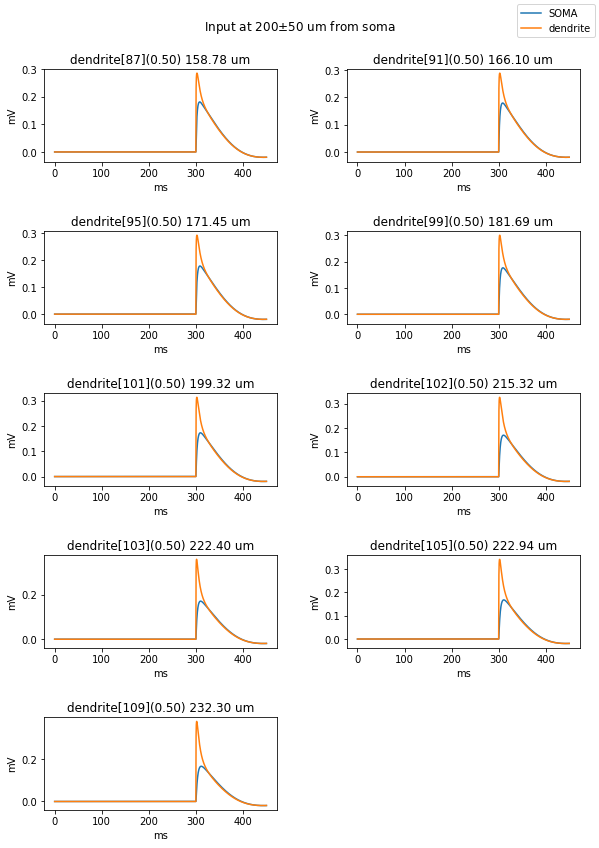

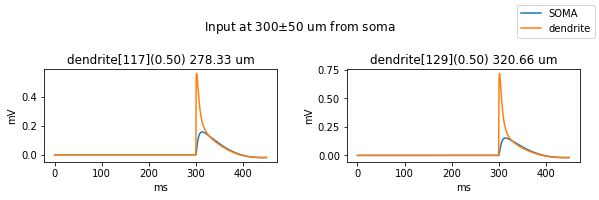

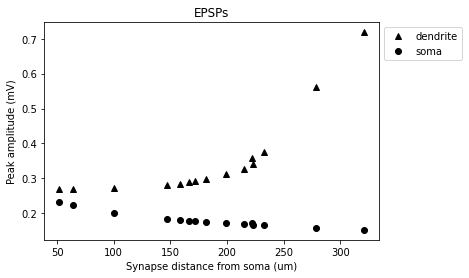

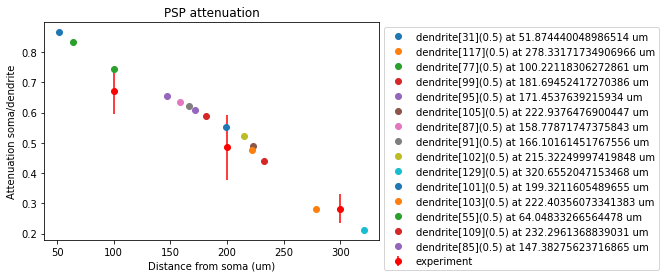

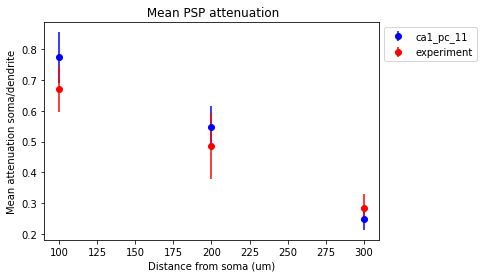

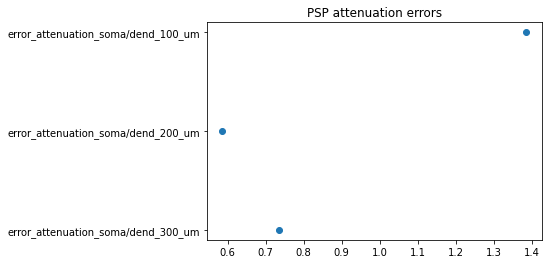

[-47.7233744163709, 0.011401720134011, 0.17866165872572, 0.110533546361937, 0.018195328014435, 4.13376819751696e-06, 0.558280689990683, -55.1977064419009, 0.000102007454842, 2.35151579716906, 0.00018773285843, 0.0, 0.082608363126436, 3.69975735209366, 0.00058114570326, 3.69310750687799, 5.1266274824495e-05, 1.15317561526235e-05, -25.8009959332103, 9.72470557972213, 9.75671751943343]
numprocs=1
Dendritic locations to be tested (with their actual distances): {('dendrite[31]', 0.5): 51.874440048986514, ('dendrite[117]', 0.5): 278.33171734906966, ('dendrite[77]', 0.5): 100.22118306272861, ('dendrite[99]', 0.5): 181.69452417270386, ('dendrite[95]', 0.5): 171.4537639215934, ('dendrite[105]', 0.5): 222.9376476900447, ('dendrite[87]', 0.5): 158.77871747375843, ('dendrite[91]', 0.5): 166.10161451767556, ('dendrite[102]', 0.5): 215.32249997419848, ('dendrite[129]', 0.5): 320.6552047153468, ('dendrite[101]', 0.5): 199.3211605489655, ('dendrite[103]', 0.5): 222.40356073341383, ('dendrite[55]', 0.5

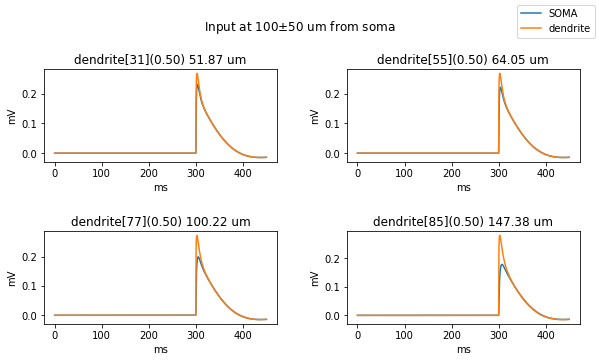

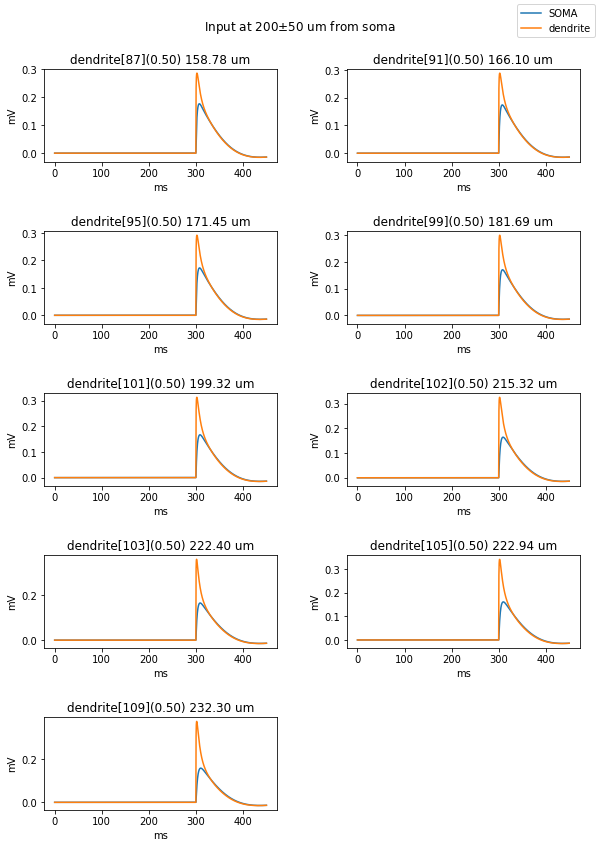

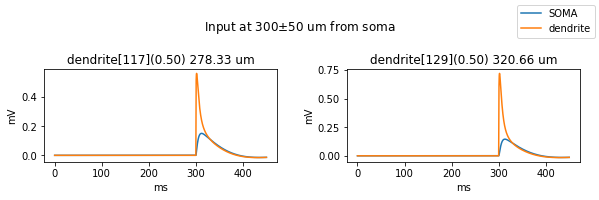

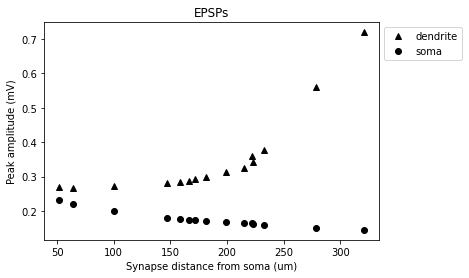

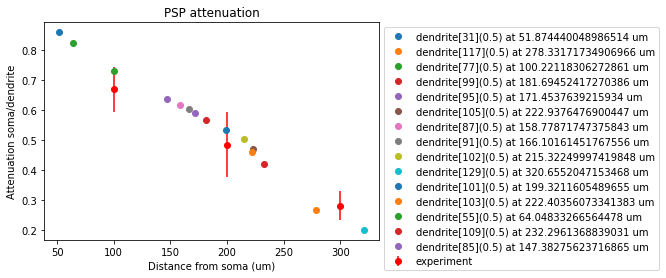

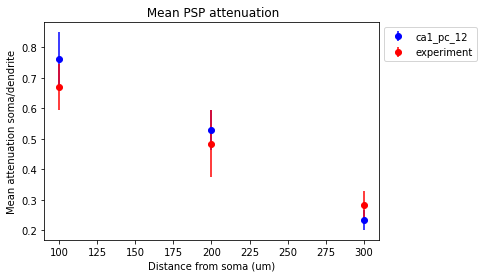

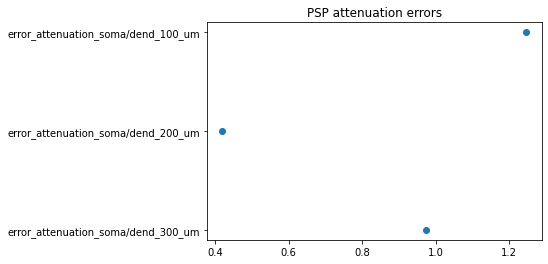

[-47.7233744163709, 0.011401720134011, 0.17866165872572, 0.110533546361937, 0.018195328014435, 4.13376819751696e-06, 0.558280689990683, -55.1977064419009, 0.000102007454842, 2.35151579716906, 0.00018773285843, 0.008177991377281, 0.0, 3.69975735209366, 0.00058114570326, 3.69310750687799, 5.1266274824495e-05, 1.15317561526235e-05, -25.8009959332103, 9.72470557972213, 9.75671751943343]
numprocs=1
Dendritic locations to be tested (with their actual distances): {('dendrite[31]', 0.5): 51.874440048986514, ('dendrite[117]', 0.5): 278.33171734906966, ('dendrite[77]', 0.5): 100.22118306272861, ('dendrite[99]', 0.5): 181.69452417270386, ('dendrite[95]', 0.5): 171.4537639215934, ('dendrite[105]', 0.5): 222.9376476900447, ('dendrite[87]', 0.5): 158.77871747375843, ('dendrite[91]', 0.5): 166.10161451767556, ('dendrite[102]', 0.5): 215.32249997419848, ('dendrite[129]', 0.5): 320.6552047153468, ('dendrite[101]', 0.5): 199.3211605489655, ('dendrite[103]', 0.5): 222.40356073341383, ('dendrite[55]', 0.5

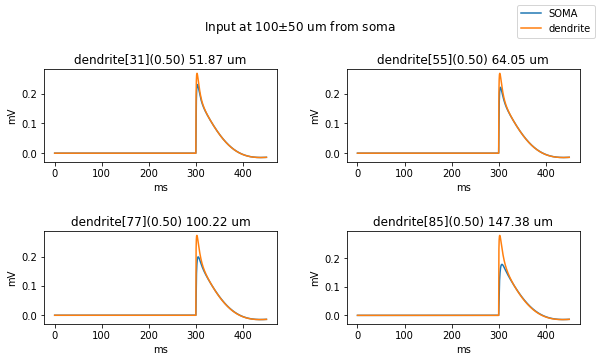

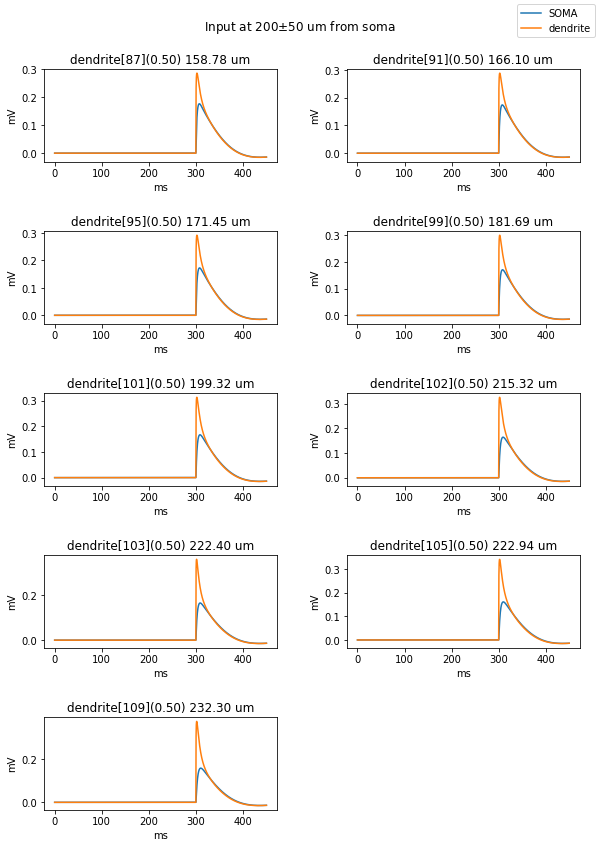

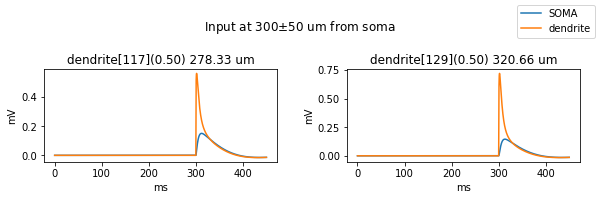

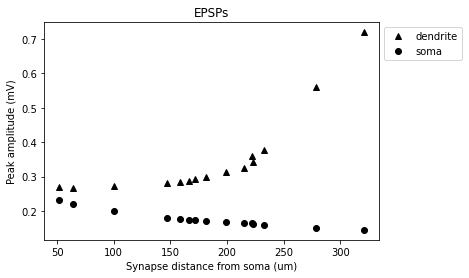

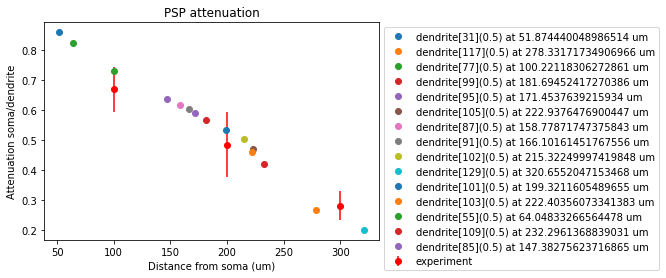

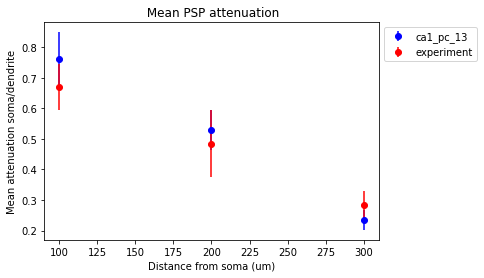

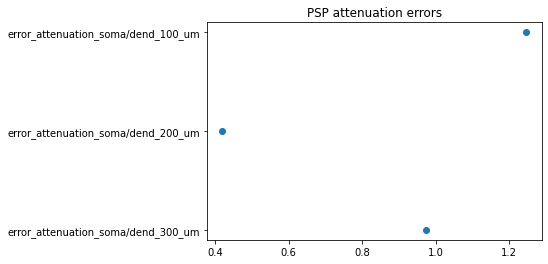

[-47.7233744163709, 0.011401720134011, 0.17866165872572, 0.110533546361937, 0.018195328014435, 4.13376819751696e-06, 0.558280689990683, -55.1977064419009, 0.000102007454842, 2.35151579716906, 0.00018773285843, 0.008177991377281, 0.082608363126436, 0.0, 0.00058114570326, 3.69310750687799, 5.1266274824495e-05, 1.15317561526235e-05, -25.8009959332103, 9.72470557972213, 9.75671751943343]
numprocs=1
Dendritic locations to be tested (with their actual distances): {('dendrite[31]', 0.5): 51.874440048986514, ('dendrite[117]', 0.5): 278.33171734906966, ('dendrite[77]', 0.5): 100.22118306272861, ('dendrite[99]', 0.5): 181.69452417270386, ('dendrite[95]', 0.5): 171.4537639215934, ('dendrite[105]', 0.5): 222.9376476900447, ('dendrite[87]', 0.5): 158.77871747375843, ('dendrite[91]', 0.5): 166.10161451767556, ('dendrite[102]', 0.5): 215.32249997419848, ('dendrite[129]', 0.5): 320.6552047153468, ('dendrite[101]', 0.5): 199.3211605489655, ('dendrite[103]', 0.5): 222.40356073341383, ('dendrite[55]', 0.

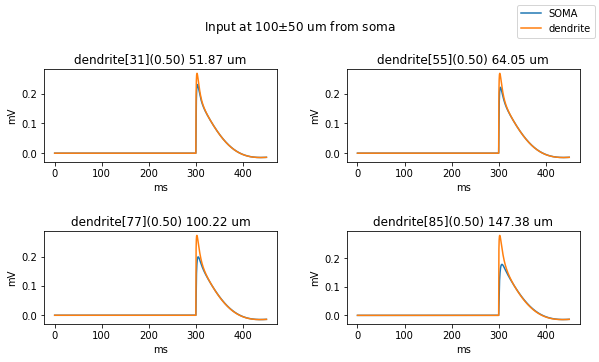

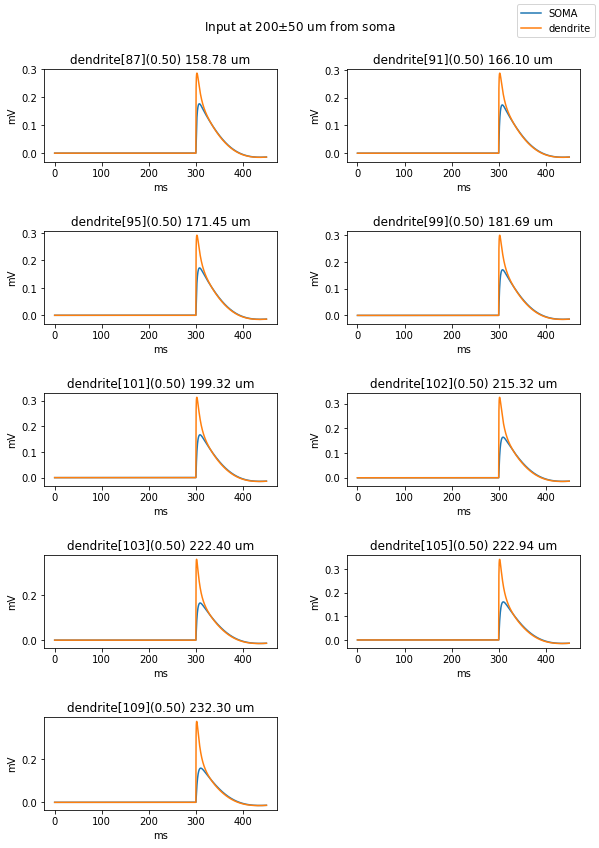

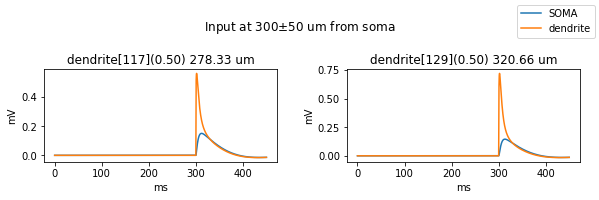

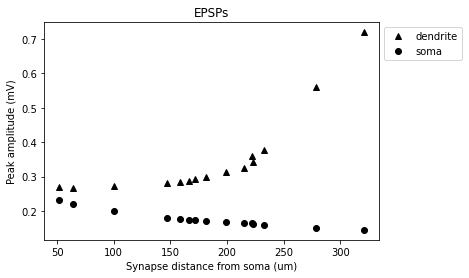

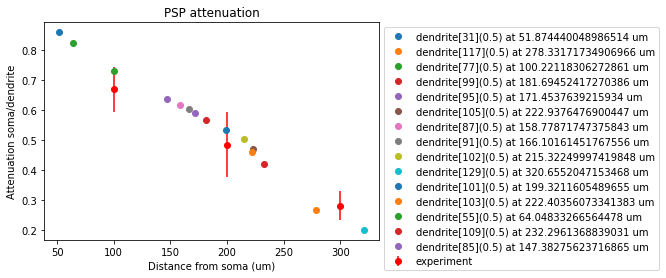

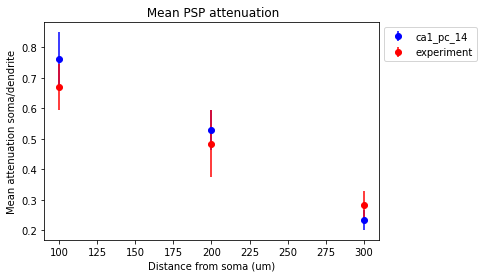

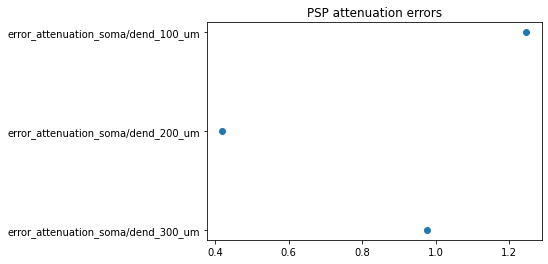

[-47.7233744163709, 0.011401720134011, 0.17866165872572, 0.110533546361937, 0.018195328014435, 4.13376819751696e-06, 0.558280689990683, -55.1977064419009, 0.000102007454842, 2.35151579716906, 0.00018773285843, 0.008177991377281, 0.082608363126436, 3.69975735209366, 0.0, 3.69310750687799, 5.1266274824495e-05, 1.15317561526235e-05, -25.8009959332103, 9.72470557972213, 9.75671751943343]
numprocs=1
Dendritic locations to be tested (with their actual distances): {('dendrite[31]', 0.5): 51.874440048986514, ('dendrite[117]', 0.5): 278.33171734906966, ('dendrite[77]', 0.5): 100.22118306272861, ('dendrite[99]', 0.5): 181.69452417270386, ('dendrite[95]', 0.5): 171.4537639215934, ('dendrite[105]', 0.5): 222.9376476900447, ('dendrite[87]', 0.5): 158.77871747375843, ('dendrite[91]', 0.5): 166.10161451767556, ('dendrite[102]', 0.5): 215.32249997419848, ('dendrite[129]', 0.5): 320.6552047153468, ('dendrite[101]', 0.5): 199.3211605489655, ('dendrite[103]', 0.5): 222.40356073341383, ('dendrite[55]', 0.

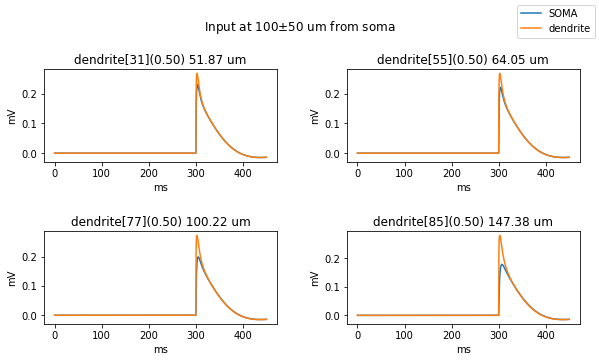

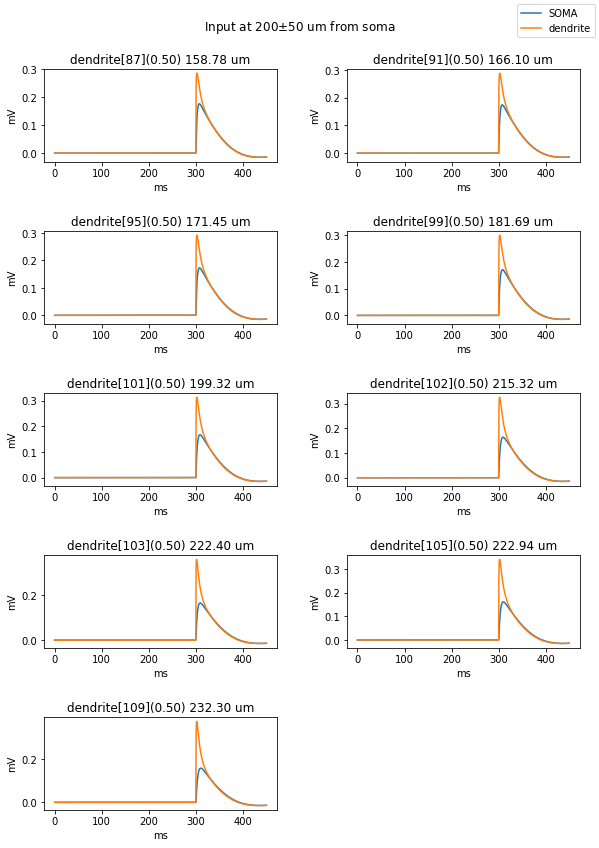

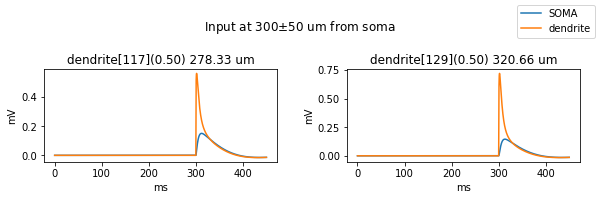

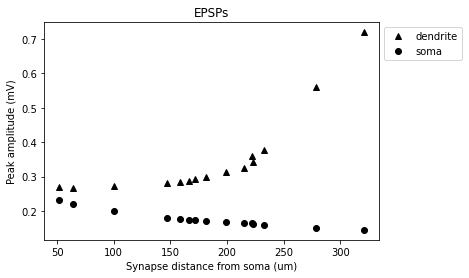

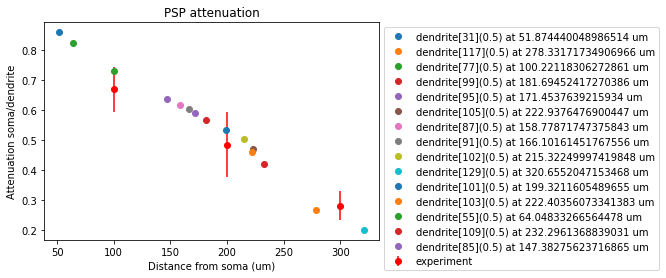

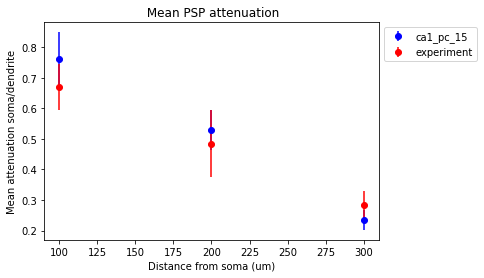

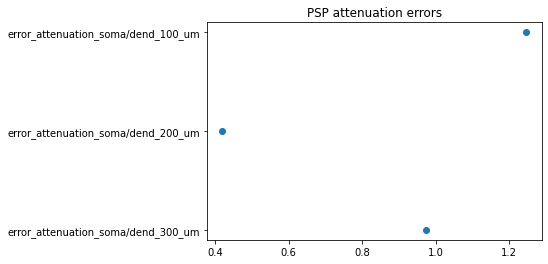

[-47.7233744163709, 0.011401720134011, 0.17866165872572, 0.110533546361937, 0.018195328014435, 4.13376819751696e-06, 0.558280689990683, -55.1977064419009, 0.000102007454842, 2.35151579716906, 0.00018773285843, 0.008177991377281, 0.082608363126436, 3.69975735209366, 0.00058114570326, 0.0, 5.1266274824495e-05, 1.15317561526235e-05, -25.8009959332103, 9.72470557972213, 9.75671751943343]
numprocs=1
Dendritic locations to be tested (with their actual distances): {('dendrite[31]', 0.5): 51.874440048986514, ('dendrite[117]', 0.5): 278.33171734906966, ('dendrite[77]', 0.5): 100.22118306272861, ('dendrite[99]', 0.5): 181.69452417270386, ('dendrite[95]', 0.5): 171.4537639215934, ('dendrite[105]', 0.5): 222.9376476900447, ('dendrite[87]', 0.5): 158.77871747375843, ('dendrite[91]', 0.5): 166.10161451767556, ('dendrite[102]', 0.5): 215.32249997419848, ('dendrite[129]', 0.5): 320.6552047153468, ('dendrite[101]', 0.5): 199.3211605489655, ('dendrite[103]', 0.5): 222.40356073341383, ('dendrite[55]', 0.

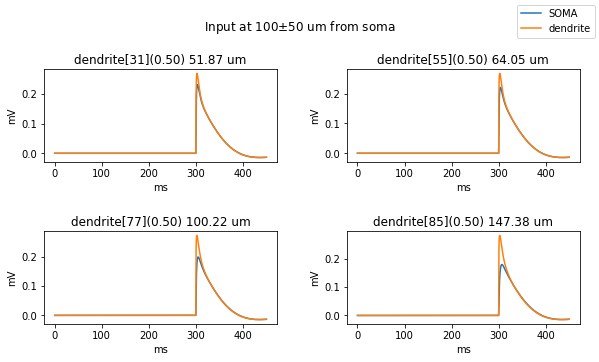

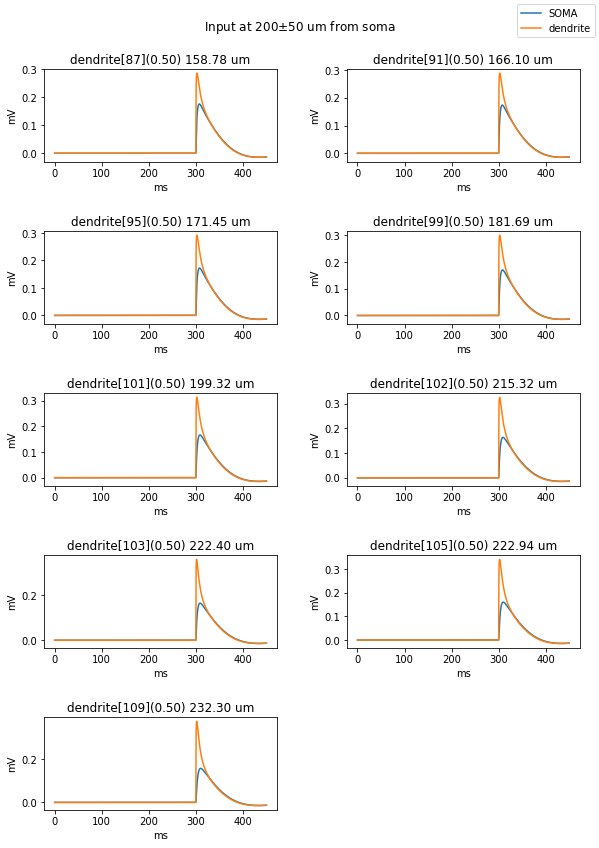

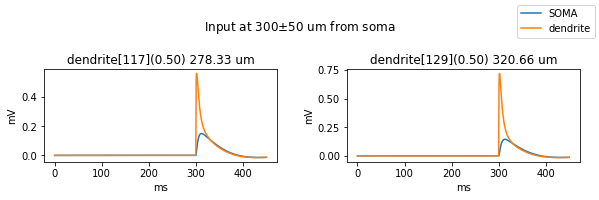

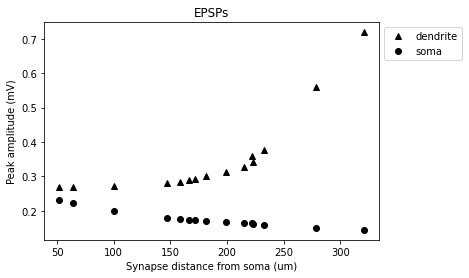

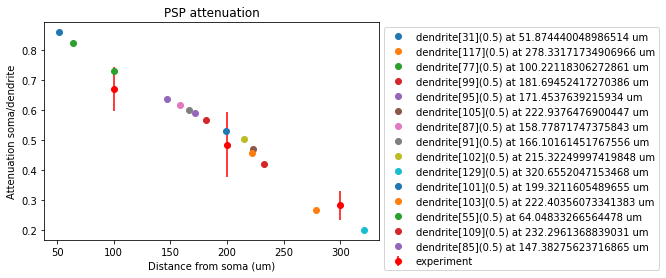

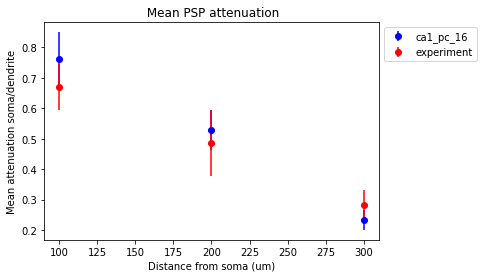

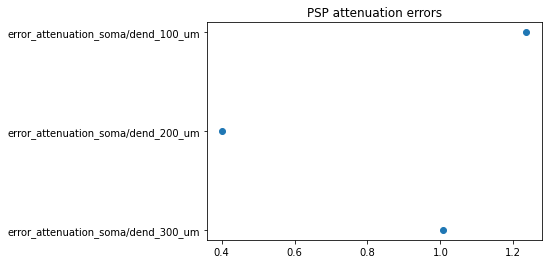

[-47.7233744163709, 0.011401720134011, 0.17866165872572, 0.110533546361937, 0.018195328014435, 4.13376819751696e-06, 0.558280689990683, -55.1977064419009, 0.000102007454842, 2.35151579716906, 0.00018773285843, 0.008177991377281, 0.082608363126436, 3.69975735209366, 0.00058114570326, 3.69310750687799, 0.0, 1.15317561526235e-05, -25.8009959332103, 9.72470557972213, 9.75671751943343]
numprocs=1
Dendritic locations to be tested (with their actual distances): {('dendrite[31]', 0.5): 51.874440048986514, ('dendrite[117]', 0.5): 278.33171734906966, ('dendrite[77]', 0.5): 100.22118306272861, ('dendrite[99]', 0.5): 181.69452417270386, ('dendrite[95]', 0.5): 171.4537639215934, ('dendrite[105]', 0.5): 222.9376476900447, ('dendrite[87]', 0.5): 158.77871747375843, ('dendrite[91]', 0.5): 166.10161451767556, ('dendrite[102]', 0.5): 215.32249997419848, ('dendrite[129]', 0.5): 320.6552047153468, ('dendrite[101]', 0.5): 199.3211605489655, ('dendrite[103]', 0.5): 222.40356073341383, ('dendrite[55]', 0.5):

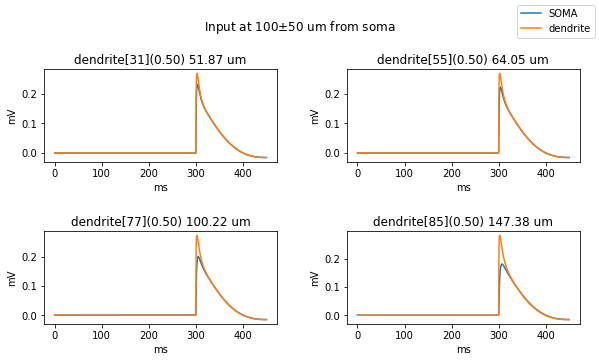

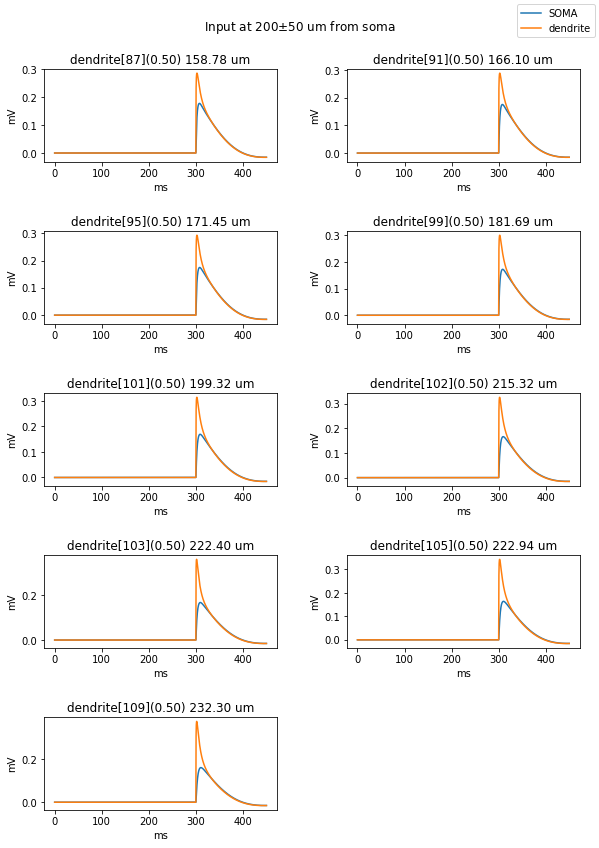

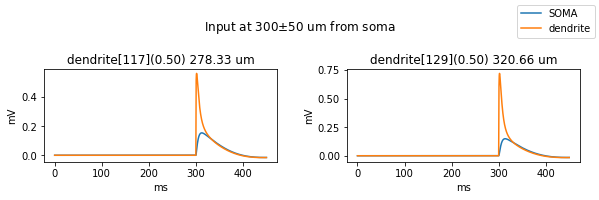

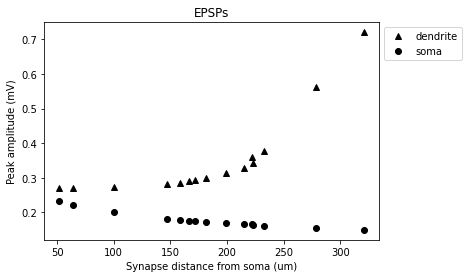

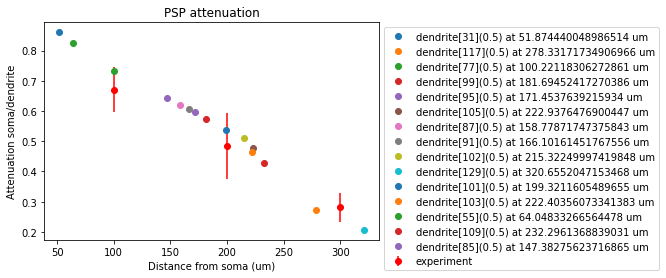

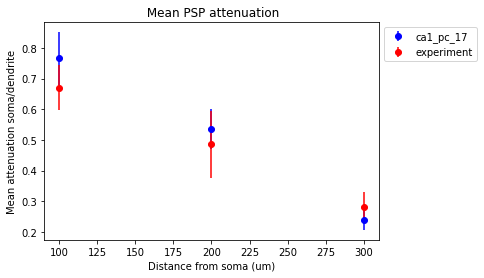

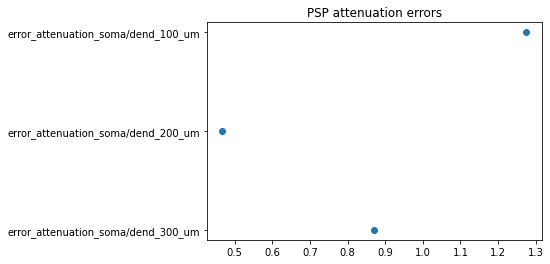

[-47.7233744163709, 0.011401720134011, 0.17866165872572, 0.110533546361937, 0.018195328014435, 4.13376819751696e-06, 0.558280689990683, -55.1977064419009, 0.000102007454842, 2.35151579716906, 0.00018773285843, 0.008177991377281, 0.082608363126436, 3.69975735209366, 0.00058114570326, 3.69310750687799, 5.1266274824495e-05, 0.0, -25.8009959332103, 9.72470557972213, 9.75671751943343]
numprocs=1
Dendritic locations to be tested (with their actual distances): {('dendrite[31]', 0.5): 51.874440048986514, ('dendrite[117]', 0.5): 278.33171734906966, ('dendrite[77]', 0.5): 100.22118306272861, ('dendrite[99]', 0.5): 181.69452417270386, ('dendrite[95]', 0.5): 171.4537639215934, ('dendrite[105]', 0.5): 222.9376476900447, ('dendrite[87]', 0.5): 158.77871747375843, ('dendrite[91]', 0.5): 166.10161451767556, ('dendrite[102]', 0.5): 215.32249997419848, ('dendrite[129]', 0.5): 320.6552047153468, ('dendrite[101]', 0.5): 199.3211605489655, ('dendrite[103]', 0.5): 222.40356073341383, ('dendrite[55]', 0.5): 

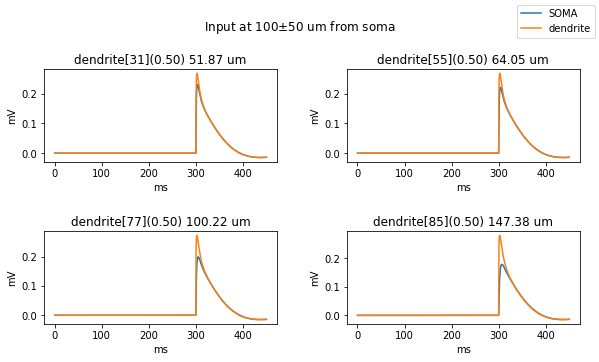

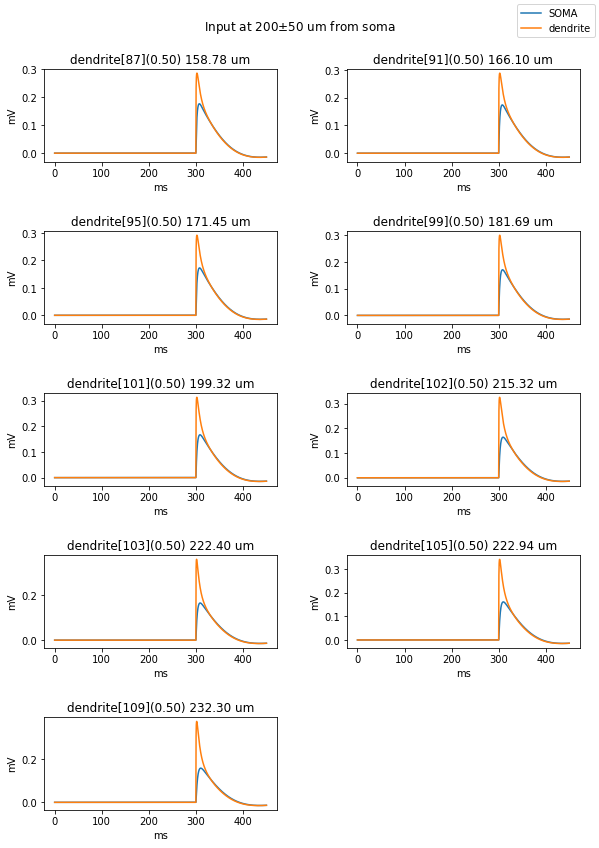

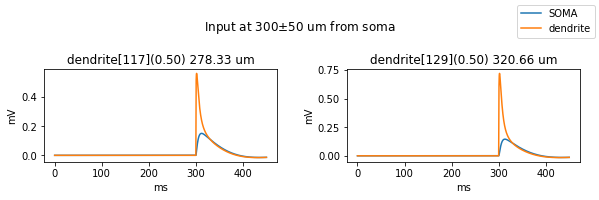

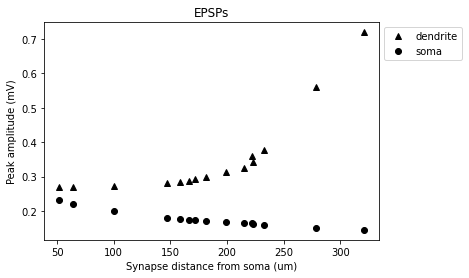

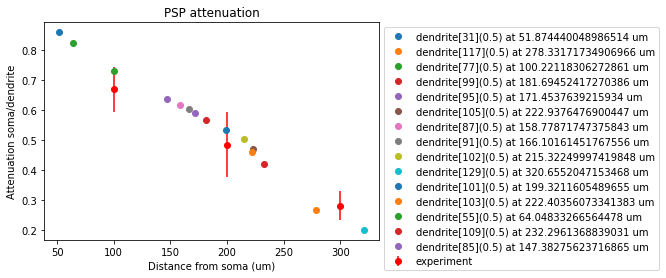

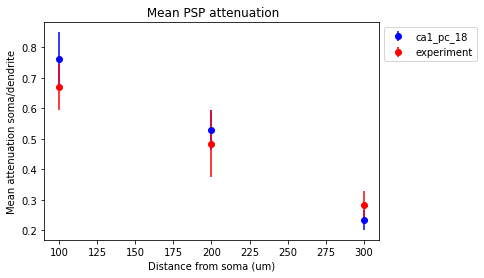

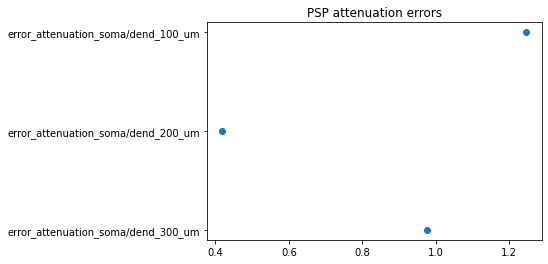

In [7]:
# Instantiate the test class
test = tests.PSPAttenuationTest(config=config, observation=observation, num_of_dend_locations = 15, force_run=True, show_plot=True, save_all = True, base_directory=base_directory)

# Number of parallel processes
test.npool = 20

"""Edit the line below"""
f = open('/home/tarluca/Modellke_story/Luca_modell_rework_2/prep_and_run_model_rework_new_K_stuff/nsg_csomag_model_rework_new/results_ca1_results/last_13_blocking.csv')
lines = []
for l in f.readlines():
    #print l.strip().split(',')
    lines.append(l.strip().split(','))
f.close()

for i in range(1, len(lines)):
    parameters = [float(j) for j in lines[i]]
    #lines[i].pop(0)
    parameters.pop(0)
    print(parameters)
    
    model.parameters = parameters
    # outputs will be saved in folders named like this:
    """Edit the line below"""
    model.name="ca1_pc_"+str(i)
    if numpy.isnan(parameters[0]):
        print('Parameters are nan')
        pass
    else:
        try:
            #Run the test 
            score = test.judge(model)
            #Summarize and print the score achieved by the model on the test using SciUnit's summarize function
            score.summarize()

        except Exception as e:
            print('Model: ' + model.name + ' could not be run')
            print(e)
            pass


In [8]:
# Load target data
"""Edit the line below"""
with open('/home/tarluca/Modellke_story/hippounit_Spine_project_20221102/hippounit/target_features/depol_block_target_data.json') as f:
    observation = json.load(f, object_pairs_hook=collections.OrderedDict)

IPython.display.HTML(json2html.convert(json = observation))

mean_Ith,0.6 nA
Ith_std,0.3 nA
mean_Veq,-40.1 mV
Veq_std,3.4 mV


[-47.7233744163709, 0.011401720134011, 0.17866165872572, 0.110533546361937, 0.018195328014435, 4.13376819751696e-06, 0.558280689990683, -55.1977064419009, 0.000102007454842, 2.35151579716906, 0.00018773285843, 0.008177991377281, 0.082608363126436, 3.69975735209366, 0.00058114570326, 3.69310750687799, 5.1266274824495e-05, 1.15317561526235e-05, -25.8009959332103, 9.72470557972213, 9.75671751943343]
- running amplitude: 0.15000000000000002 on model: ca1_pc_1 at: soma(0.5)
- running amplitude: 0.1 on model: ca1_pc_1 at: soma(0.5)
- running amplitude: 0.0 on model: ca1_pc_1 at: soma(0.5)
- running amplitude: 0.5 on model: ca1_pc_1 at: soma(0.5)
- running amplitude: 0.75 on model: ca1_pc_1 at: soma(0.5)
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
- running amplitude: 0.25 on model: ca1_pc_1 at: soma(0.5)- running ampli

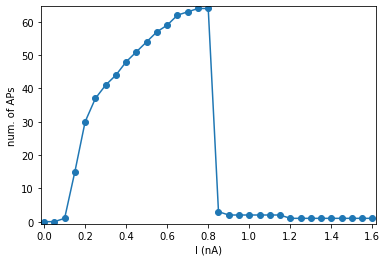

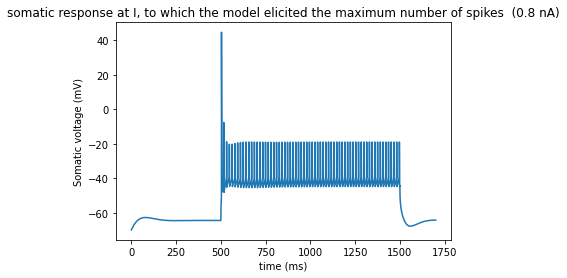

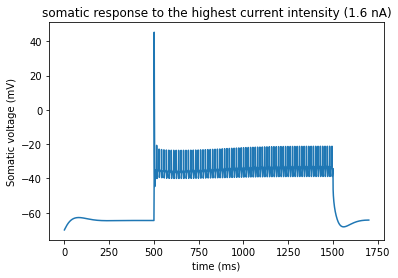

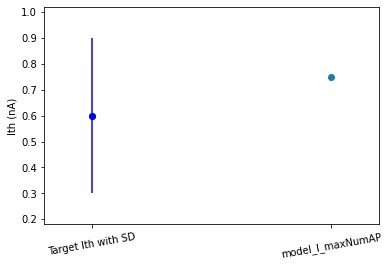

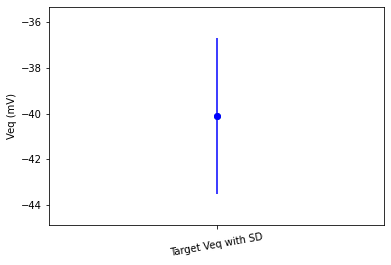

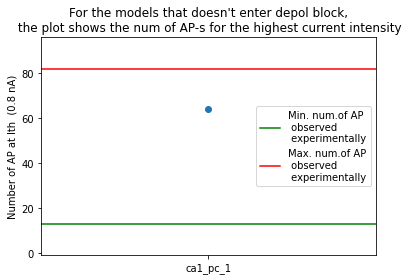

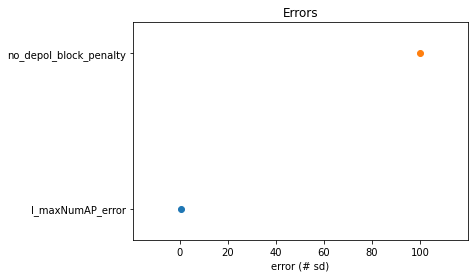

The model did not enter depolarization block.
[-47.7233744163709, 0.0, 0.17866165872572, 0.110533546361937, 0.018195328014435, 4.13376819751696e-06, 0.558280689990683, -55.1977064419009, 0.000102007454842, 2.35151579716906, 0.00018773285843, 0.008177991377281, 0.082608363126436, 3.69975735209366, 0.00058114570326, 3.69310750687799, 5.1266274824495e-05, 1.15317561526235e-05, -25.8009959332103, 9.72470557972213, 9.75671751943343]
- running amplitude: 0.4 on model: ca1_pc_2 at: soma(0.5)
- running amplitude: 0.15000000000000002 on model: ca1_pc_2 at: soma(0.5)
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
- running amplitude: 0.30000000000000004 on model: ca1_pc_2 at: soma(0.5)- running amplitude: 0.05 on model: ca1_pc_2 at: soma(0.5)- running amplitude: 0.9500000000000001 on model: ca1_pc_2 at: soma(0.5)


- running 

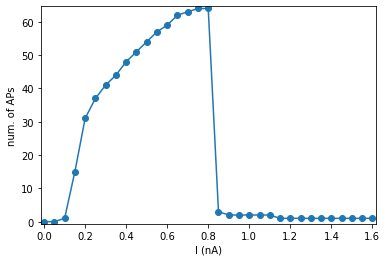

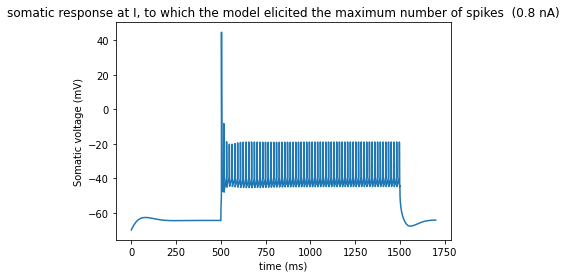

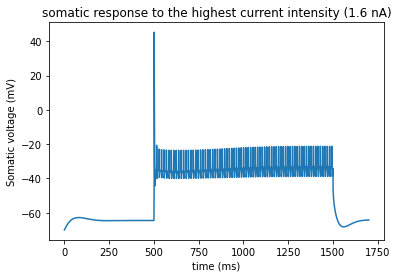

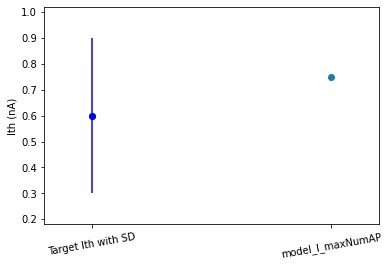

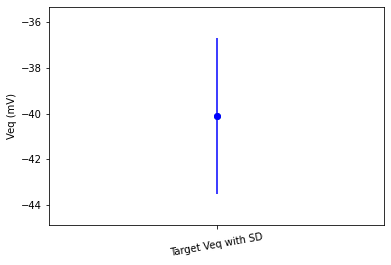

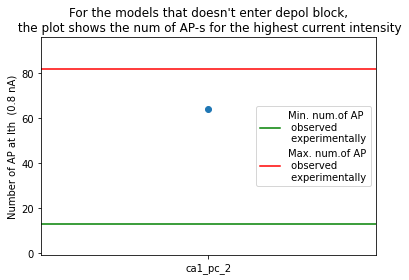

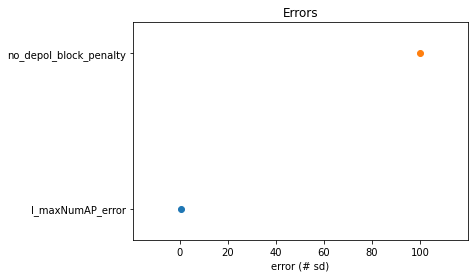

The model did not enter depolarization block.
[-47.7233744163709, 0.011401720134011, 0.0, 0.110533546361937, 0.018195328014435, 4.13376819751696e-06, 0.558280689990683, -55.1977064419009, 0.000102007454842, 2.35151579716906, 0.00018773285843, 0.008177991377281, 0.082608363126436, 3.69975735209366, 0.00058114570326, 3.69310750687799, 5.1266274824495e-05, 1.15317561526235e-05, -25.8009959332103, 9.72470557972213, 9.75671751943343]
- running amplitude: 0.7000000000000001 on model: ca1_pc_3 at: soma(0.5)
- running amplitude: 0.9500000000000001 on model: ca1_pc_3 at: soma(0.5)
- running amplitude: 0.6000000000000001 on model: ca1_pc_3 at: soma(0.5)
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
- running amplitude: 0.2 on model: ca1_pc_3 at: soma(0.5)
- running amplitude: 0.0 on model: ca1_pc_3 at: soma(0.5)- running amp

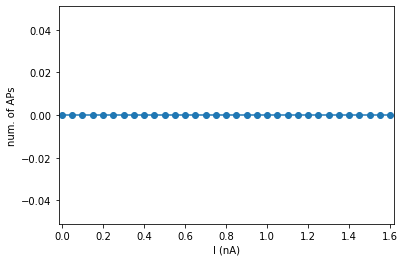

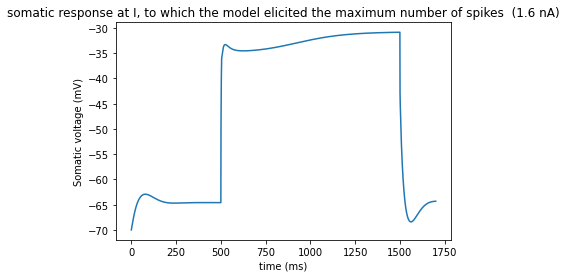

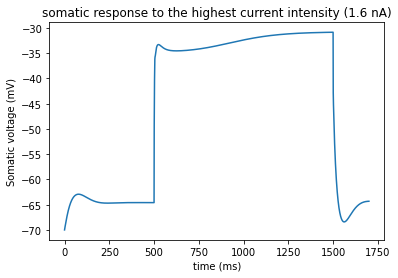

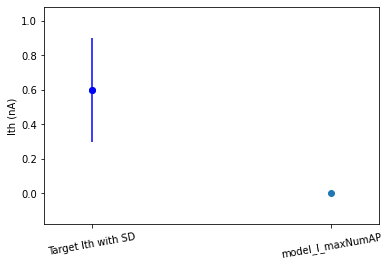

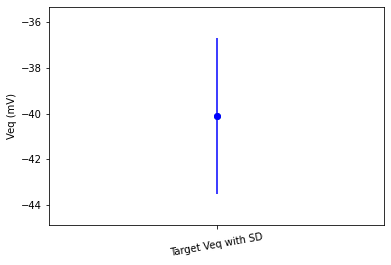

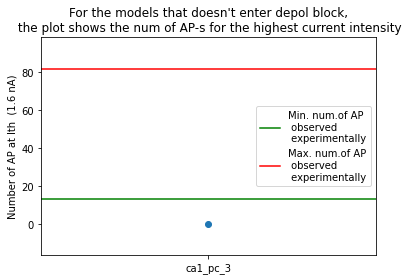

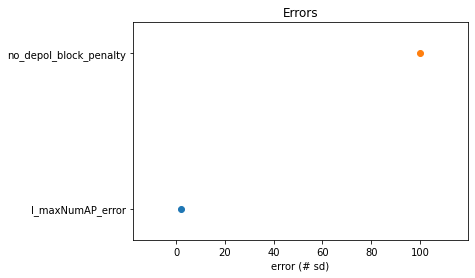

The model did not enter depolarization block.
[-47.7233744163709, 0.011401720134011, 0.17866165872572, 0.0, 0.018195328014435, 4.13376819751696e-06, 0.558280689990683, -55.1977064419009, 0.000102007454842, 2.35151579716906, 0.00018773285843, 0.008177991377281, 0.082608363126436, 3.69975735209366, 0.00058114570326, 3.69310750687799, 5.1266274824495e-05, 1.15317561526235e-05, -25.8009959332103, 9.72470557972213, 9.75671751943343]
- running amplitude: 0.9 on model: ca1_pc_4 at: soma(0.5)- running amplitude: 0.4 on model: ca1_pc_4 at: soma(0.5)

numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
- running amplitude: 0.05 on model: ca1_pc_4 at: soma(0.5)
- running amplitude: 0.8500000000000001 on model: ca1_pc_4 at: soma(0.5)
- running amplitude: 0.2 on model: ca1_pc_4 at: soma(0.5)- running amplitude: 0.9500000000000001 on 

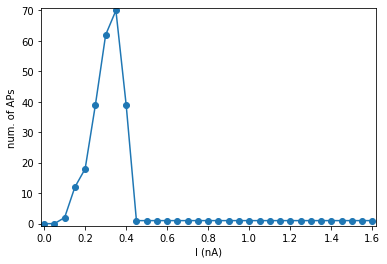

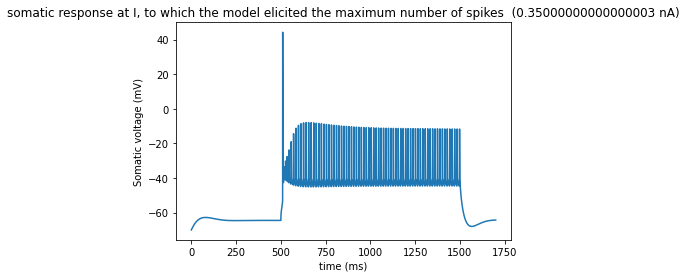

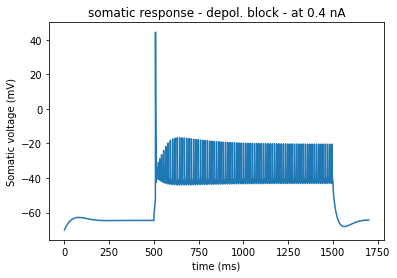

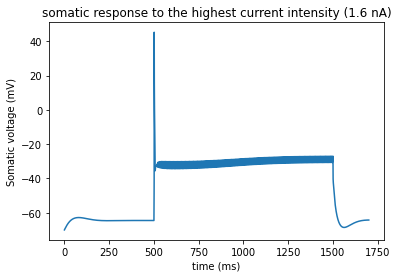

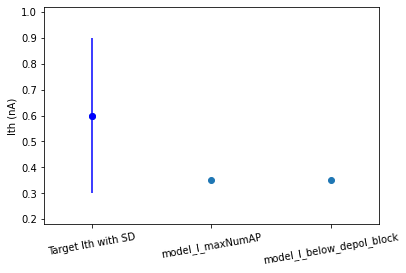

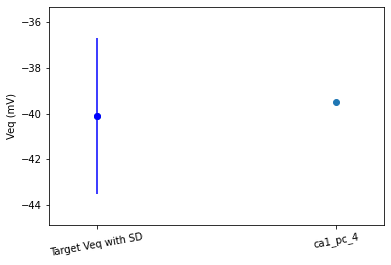

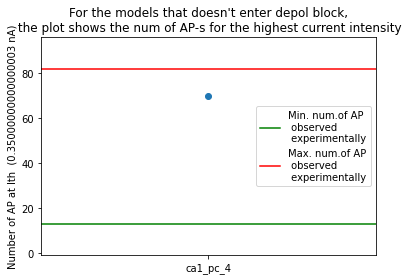

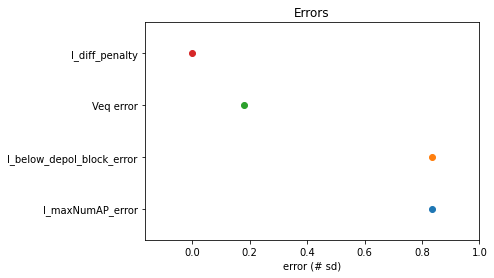

[-47.7233744163709, 0.0, 0.17866165872572, 0.0, 0.018195328014435, 4.13376819751696e-06, 0.558280689990683, -55.1977064419009, 0.000102007454842, 2.35151579716906, 0.00018773285843, 0.008177991377281, 0.082608363126436, 3.69975735209366, 0.00058114570326, 3.69310750687799, 5.1266274824495e-05, 1.15317561526235e-05, -25.8009959332103, 9.72470557972213, 9.75671751943343]
- running amplitude: 0.8 on model: ca1_pc_5 at: soma(0.5)
- running amplitude: 0.05 on model: ca1_pc_5 at: soma(0.5)
- running amplitude: 0.2 on model: ca1_pc_5 at: soma(0.5)
- running amplitude: 0.4 on model: ca1_pc_5 at: soma(0.5)
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
- running amplitude: 0.0 on model: ca1_pc_5 at: soma(0.5)
- running amplitude: 0.1 on model: ca1_pc_5 at: soma(0.5)
- running amplitude: 0.15000000000000002 on model: ca1_pc_5

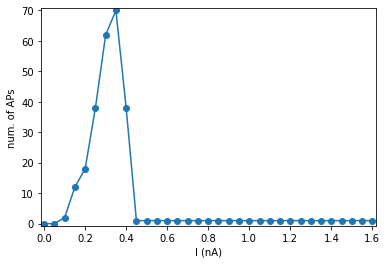

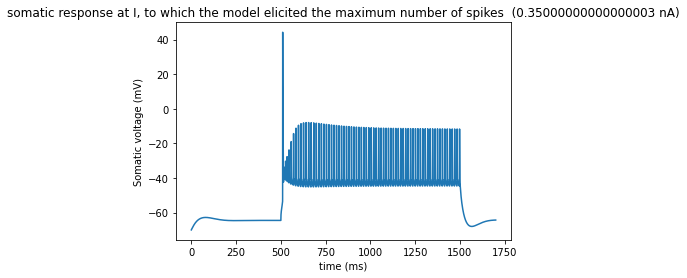

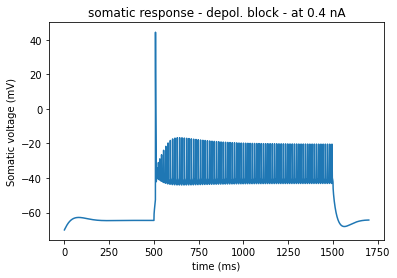

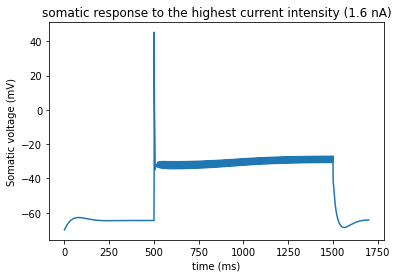

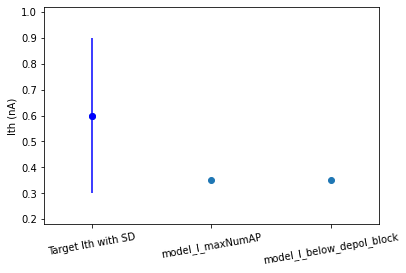

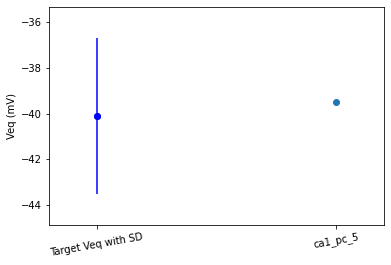

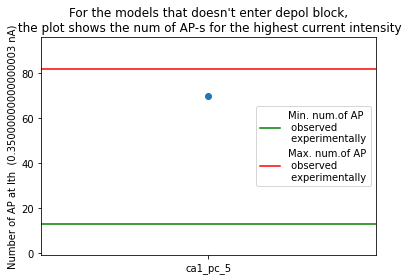

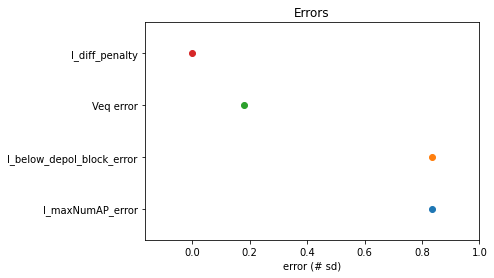

[-47.7233744163709, 0.011401720134011, 0.17866165872572, 0.110533546361937, 0.0, 4.13376819751696e-06, 0.558280689990683, -55.1977064419009, 0.000102007454842, 2.35151579716906, 0.00018773285843, 0.008177991377281, 0.082608363126436, 3.69975735209366, 0.00058114570326, 3.69310750687799, 5.1266274824495e-05, 1.15317561526235e-05, -25.8009959332103, 9.72470557972213, 9.75671751943343]
- running amplitude: 0.45 on model: ca1_pc_6 at: soma(0.5)
- running amplitude: 0.35000000000000003 on model: ca1_pc_6 at: soma(0.5)
- running amplitude: 0.9 on model: ca1_pc_6 at: soma(0.5)
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
- running amplitude: 0.8 on model: ca1_pc_6 at: soma(0.5)
- running amplitude: 0.30000000000000004 on model: ca1_pc_6 at: soma(0.5)
- running amplitude: 0.7000000000000001 on model: ca1_pc_6 at: soma(0.5

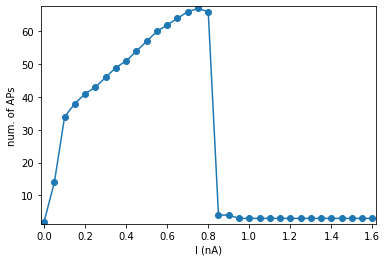

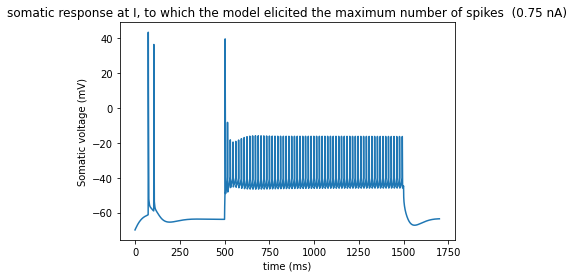

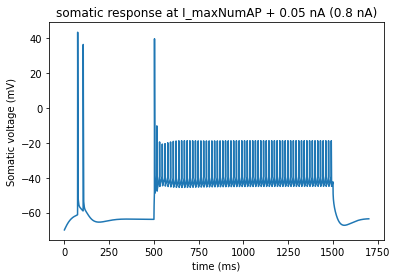

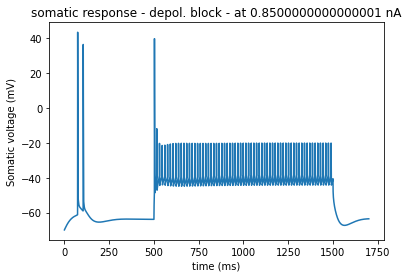

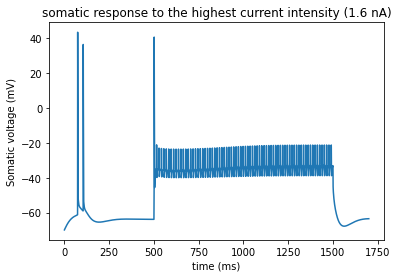

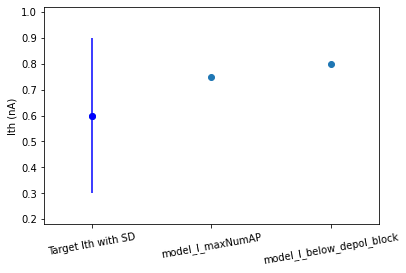

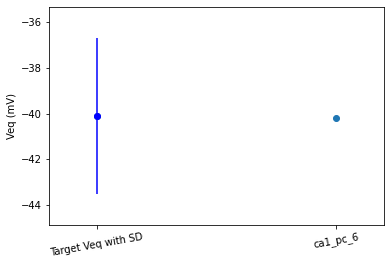

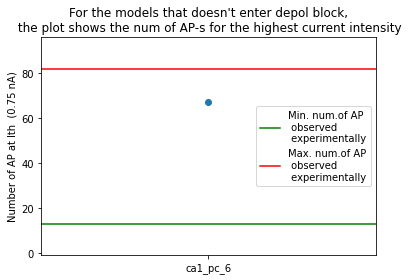

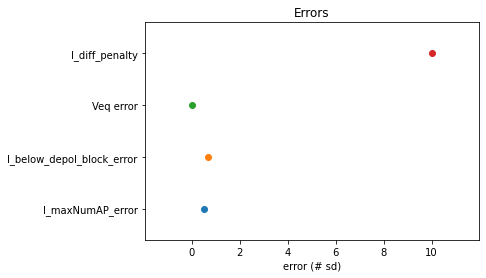

[-47.7233744163709, 0.011401720134011, 0.17866165872572, 0.110533546361937, 0.018195328014435, 4.13376819751696e-06, 0.0, -55.1977064419009, 0.000102007454842, 2.35151579716906, 0.00018773285843, 0.008177991377281, 0.082608363126436, 3.69975735209366, 0.00058114570326, 3.69310750687799, 5.1266274824495e-05, 1.15317561526235e-05, -25.8009959332103, 9.72470557972213, 9.75671751943343]
- running amplitude: 0.35000000000000003 on model: ca1_pc_7 at: soma(0.5)
- running amplitude: 0.30000000000000004 on model: ca1_pc_7 at: soma(0.5)
- running amplitude: 0.55 on model: ca1_pc_7 at: soma(0.5)
- running amplitude: 0.25 on model: ca1_pc_7 at: soma(0.5)- running amplitude: 0.9500000000000001 on model: ca1_pc_7 at: soma(0.5)

- running amplitude: 0.5 on model: ca1_pc_7 at: soma(0.5)
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs

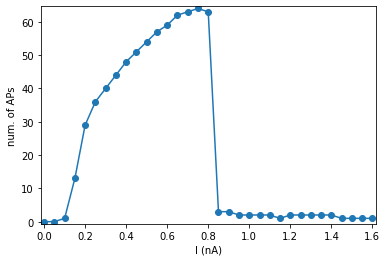

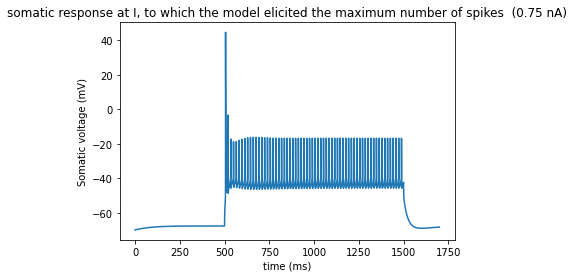

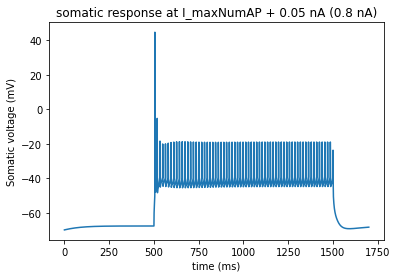

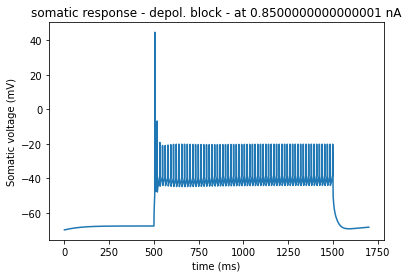

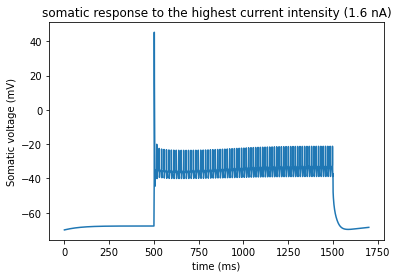

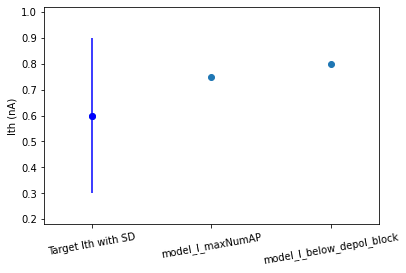

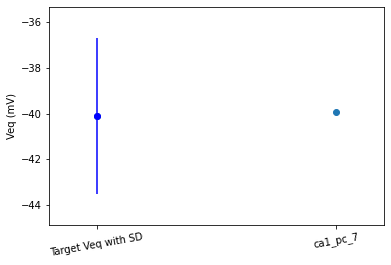

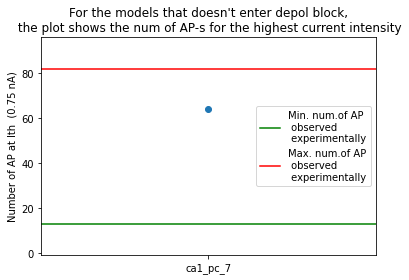

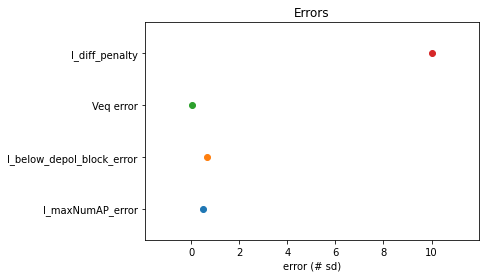

[-47.7233744163709, 0.011401720134011, 0.17866165872572, 0.110533546361937, 0.018195328014435, 4.13376819751696e-06, 0.558280689990683, -55.1977064419009, 0.0, 2.35151579716906, 0.00018773285843, 0.008177991377281, 0.082608363126436, 3.69975735209366, 0.00058114570326, 3.69310750687799, 5.1266274824495e-05, 1.15317561526235e-05, -25.8009959332103, 9.72470557972213, 9.75671751943343]
- running amplitude: 0.35000000000000003 on model: ca1_pc_8 at: soma(0.5)
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
- running amplitude: 0.45 on model: ca1_pc_8 at: soma(0.5)
- running amplitude: 0.25 on model: ca1_pc_8 at: soma(0.5)- running amplitude: 0.6000000000000001 on model: ca1_pc_8 at: soma(0.5)

- running amplitude: 0.65 on model: ca1_pc_8 at: soma(0.5)
- running amplitude: 0.7000000000000001 on model: ca1_pc_8 at: soma(0.

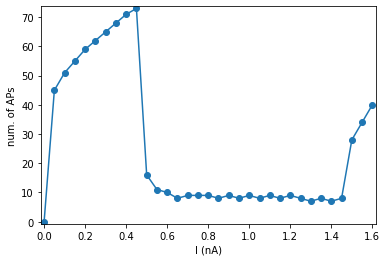

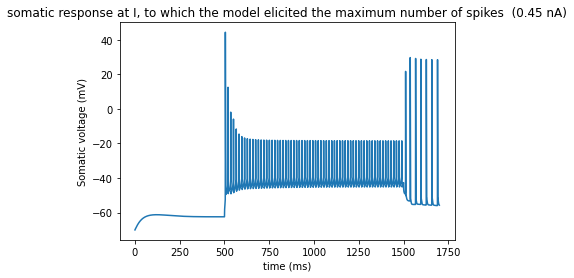

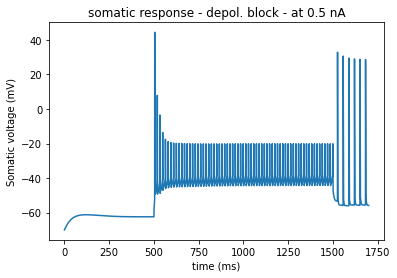

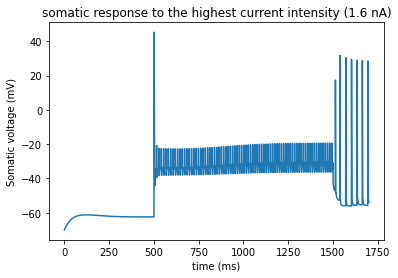

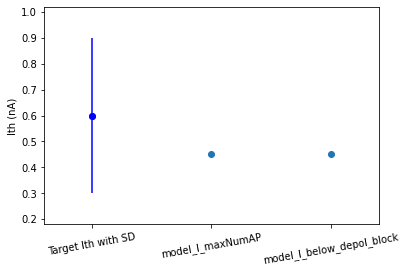

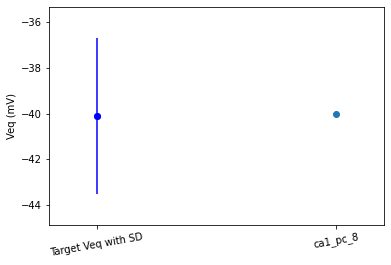

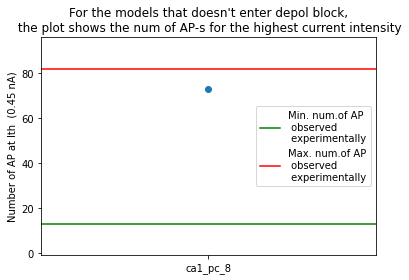

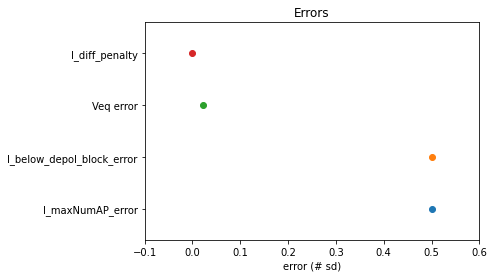

[-47.7233744163709, 0.011401720134011, 0.17866165872572, 0.110533546361937, 0.018195328014435, 4.13376819751696e-06, 0.558280689990683, -55.1977064419009, 0.000102007454842, 0.0, 0.00018773285843, 0.008177991377281, 0.082608363126436, 3.69975735209366, 0.00058114570326, 3.69310750687799, 5.1266274824495e-05, 1.15317561526235e-05, -25.8009959332103, 9.72470557972213, 9.75671751943343]
- running amplitude: 0.5 on model: ca1_pc_9 at: soma(0.5)- running amplitude: 0.6000000000000001 on model: ca1_pc_9 at: soma(0.5)

- running amplitude: 0.9 on model: ca1_pc_9 at: soma(0.5)
- running amplitude: 0.25 on model: ca1_pc_9 at: soma(0.5)
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
- running amplitude: 0.05 on model: ca1_pc_9 at: soma(0.5)
- running amplitude: 0.0 on model: ca1_pc_9 at: soma(0.5)- running amplitude: 0.45 on 

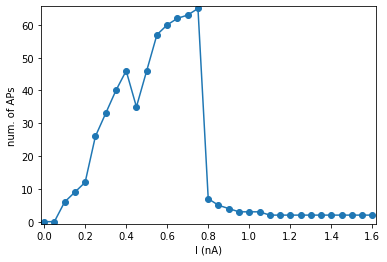

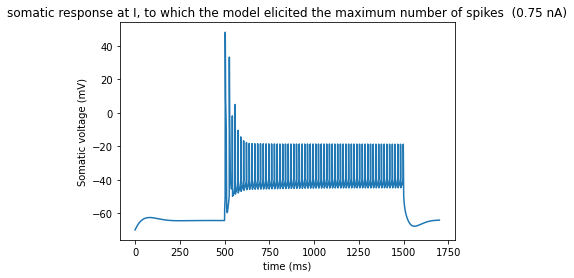

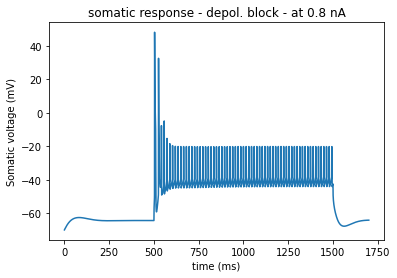

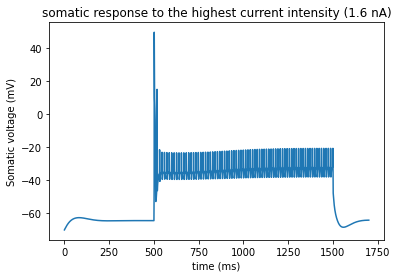

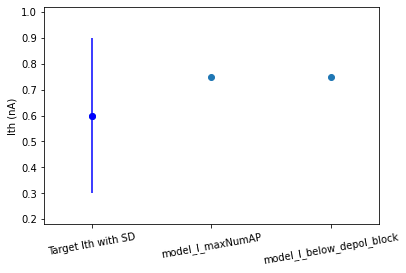

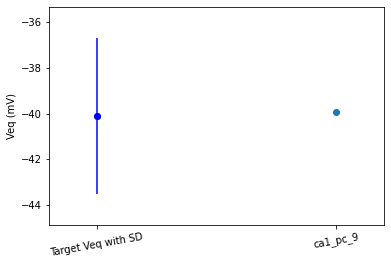

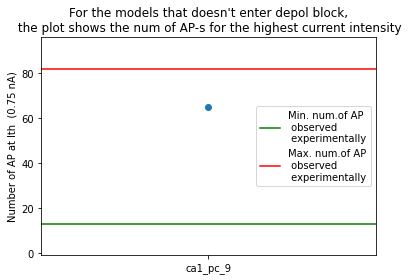

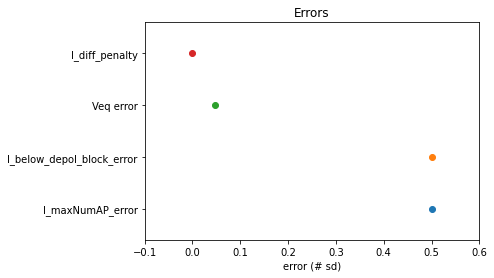

[-47.7233744163709, 0.011401720134011, 0.17866165872572, 0.110533546361937, 0.018195328014435, 4.13376819751696e-06, 0.558280689990683, -55.1977064419009, 0.000102007454842, 2.35151579716906, 0.0, 0.008177991377281, 0.082608363126436, 3.69975735209366, 0.00058114570326, 3.69310750687799, 5.1266274824495e-05, 1.15317561526235e-05, -25.8009959332103, 9.72470557972213, 9.75671751943343]
- running amplitude: 0.8 on model: ca1_pc_10 at: soma(0.5)
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
- running amplitude: 0.30000000000000004 on model: ca1_pc_10 at: soma(0.5)- running amplitude: 0.15000000000000002 on model: ca1_pc_10 at: soma(0.5)
- running amplitude: 0.35000000000000003 on model: ca1_pc_10 at: soma(0.5)
- running amplitude: 0.45 on model: ca1_pc_10 at: soma(0.5)

- running amplitude: 0.2 on model: ca1_pc_10 at: 

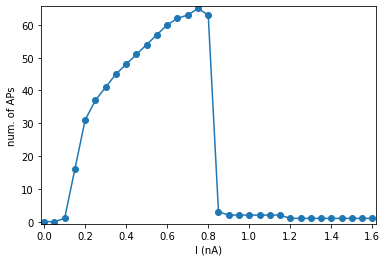

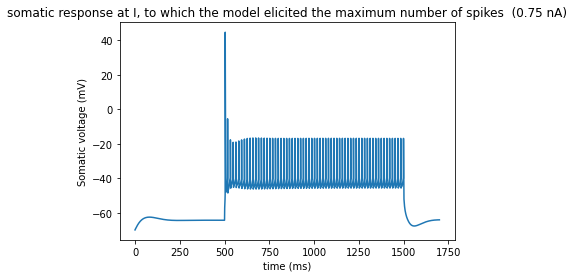

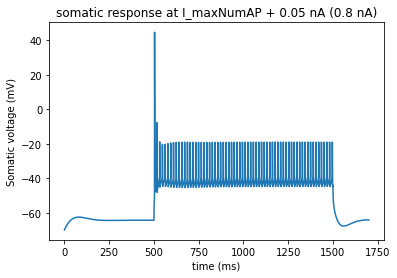

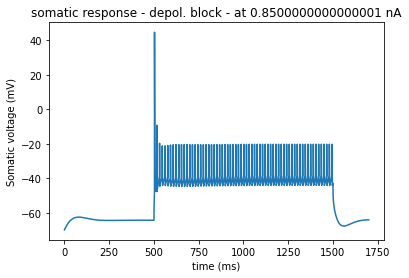

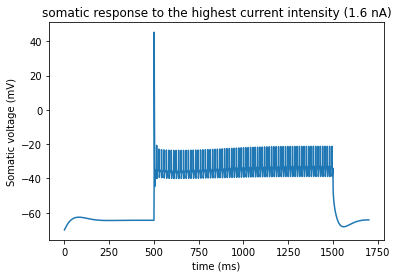

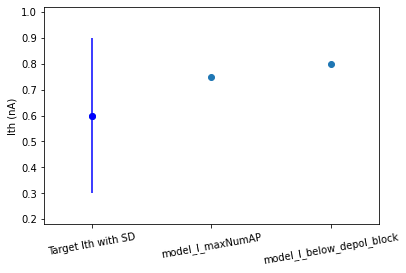

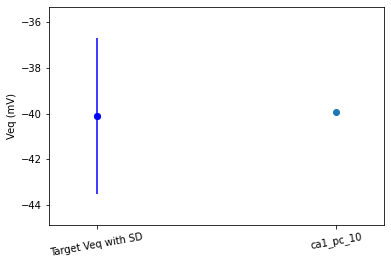

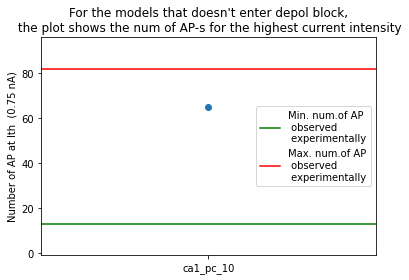

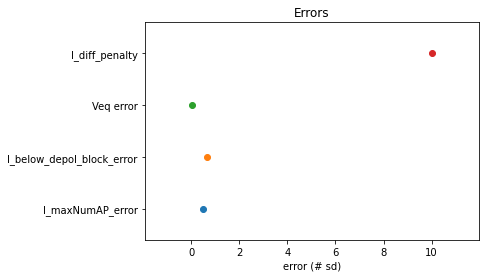

[-47.7233744163709, 0.011401720134011, 0.17866165872572, 0.110533546361937, 0.0, 4.13376819751696e-06, 0.558280689990683, -55.1977064419009, 0.000102007454842, 2.35151579716906, 0.0, 0.008177991377281, 0.082608363126436, 3.69975735209366, 0.00058114570326, 3.69310750687799, 5.1266274824495e-05, 1.15317561526235e-05, -25.8009959332103, 9.72470557972213, 9.75671751943343]
- running amplitude: 0.2 on model: ca1_pc_11 at: soma(0.5)
- running amplitude: 0.75 on model: ca1_pc_11 at: soma(0.5)
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
- running amplitude: 0.1 on model: ca1_pc_11 at: soma(0.5)
- running amplitude: 0.15000000000000002 on model: ca1_pc_11 at: soma(0.5)
- running amplitude: 0.55 on model: ca1_pc_11 at: soma(0.5)
- running amplitude: 0.0 on model: ca1_pc_11 at: soma(0.5)
- running amplitude: 0.4 on model: 

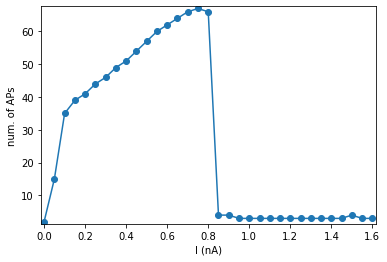

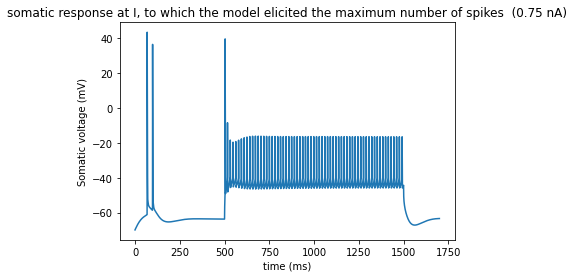

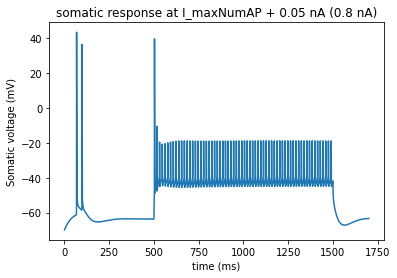

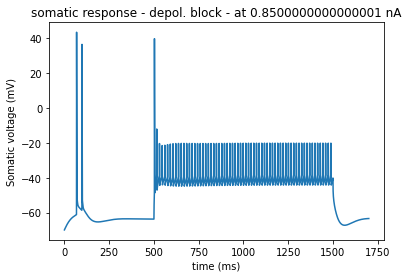

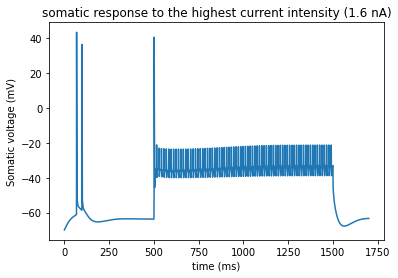

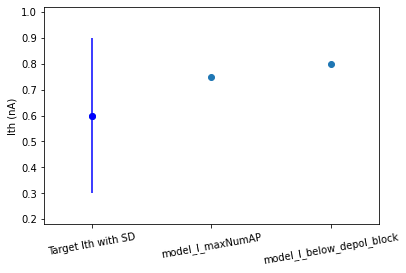

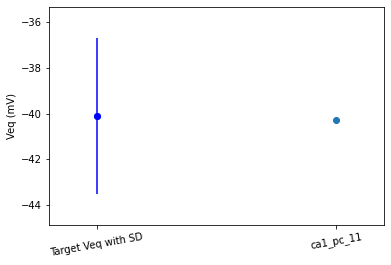

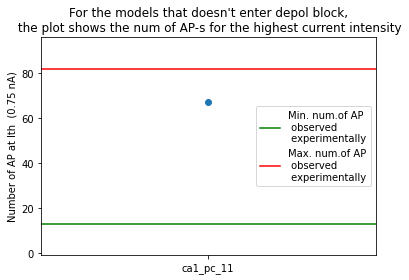

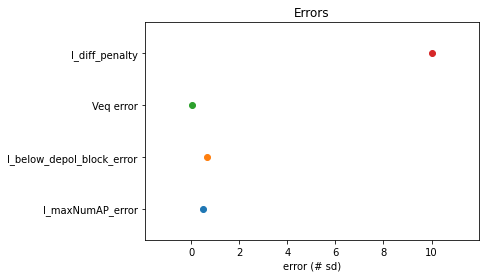

[-47.7233744163709, 0.011401720134011, 0.17866165872572, 0.110533546361937, 0.018195328014435, 4.13376819751696e-06, 0.558280689990683, -55.1977064419009, 0.000102007454842, 2.35151579716906, 0.00018773285843, 0.0, 0.082608363126436, 3.69975735209366, 0.00058114570326, 3.69310750687799, 5.1266274824495e-05, 1.15317561526235e-05, -25.8009959332103, 9.72470557972213, 9.75671751943343]
- running amplitude: 0.15000000000000002 on model: ca1_pc_12 at: soma(0.5)
- running amplitude: 0.9500000000000001 on model: ca1_pc_12 at: soma(0.5)
- running amplitude: 0.9 on model: ca1_pc_12 at: soma(0.5)
- running amplitude: 0.55 on model: ca1_pc_12 at: soma(0.5)- running amplitude: 0.25 on model: ca1_pc_12 at: soma(0.5)- running amplitude: 0.30000000000000004 on model: ca1_pc_12 at: soma(0.5)


numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
nu

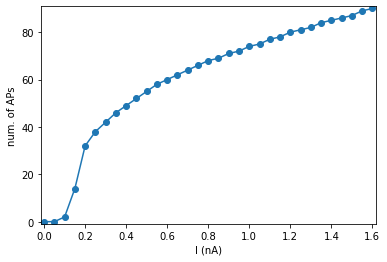

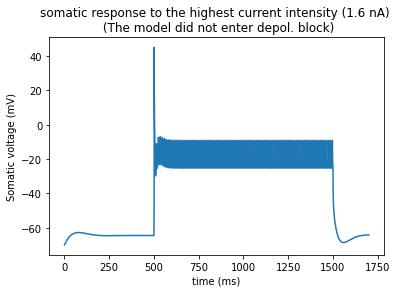

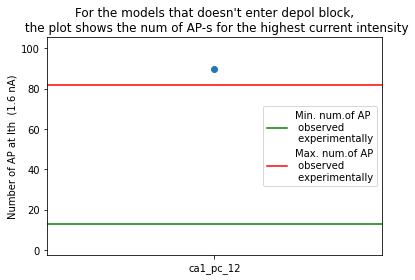

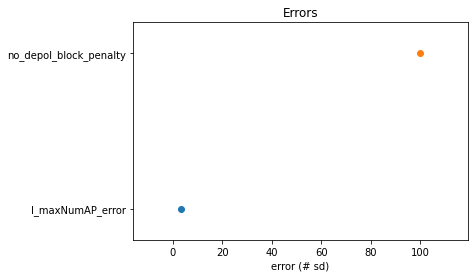

The model did not enter depolarization block.
[-47.7233744163709, 0.011401720134011, 0.17866165872572, 0.110533546361937, 0.018195328014435, 4.13376819751696e-06, 0.558280689990683, -55.1977064419009, 0.000102007454842, 2.35151579716906, 0.00018773285843, 0.008177991377281, 0.0, 3.69975735209366, 0.00058114570326, 3.69310750687799, 5.1266274824495e-05, 1.15317561526235e-05, -25.8009959332103, 9.72470557972213, 9.75671751943343]
- running amplitude: 0.35000000000000003 on model: ca1_pc_13 at: soma(0.5)
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
- running amplitude: 0.65 on model: ca1_pc_13 at: soma(0.5)
- running amplitude: 0.05 on model: ca1_pc_13 at: soma(0.5)
- running amplitude: 0.45 on model: ca1_pc_13 at: soma(0.5)- running amplitude: 0.5 on model: ca1_pc_13 at: soma(0.5)

- running amplitude: 0.75 on model

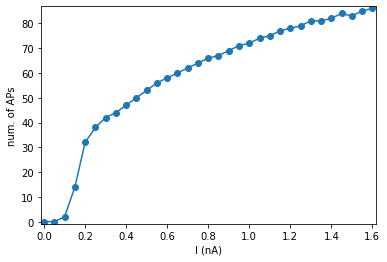

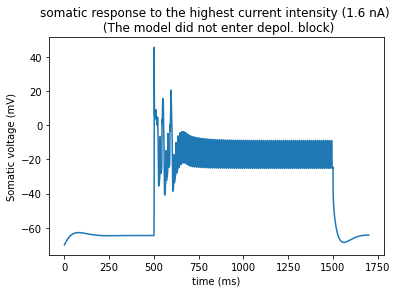

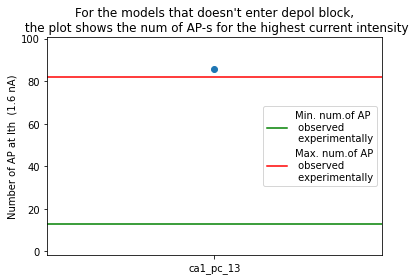

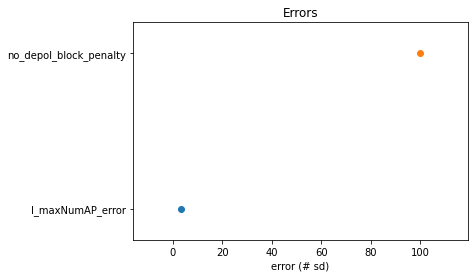

The model did not enter depolarization block.
[-47.7233744163709, 0.011401720134011, 0.17866165872572, 0.110533546361937, 0.018195328014435, 4.13376819751696e-06, 0.558280689990683, -55.1977064419009, 0.000102007454842, 2.35151579716906, 0.00018773285843, 0.008177991377281, 0.082608363126436, 0.0, 0.00058114570326, 3.69310750687799, 5.1266274824495e-05, 1.15317561526235e-05, -25.8009959332103, 9.72470557972213, 9.75671751943343]
- running amplitude: 0.7000000000000001 on model: ca1_pc_14 at: soma(0.5)
- running amplitude: 0.9 on model: ca1_pc_14 at: soma(0.5)
- running amplitude: 0.5 on model: ca1_pc_14 at: soma(0.5)- running amplitude: 0.2 on model: ca1_pc_14 at: soma(0.5)

numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
- running amplitude: 0.1 on model: ca1_pc_14 at: soma(0.5)
- running amplitude: 0.4 on model: ca

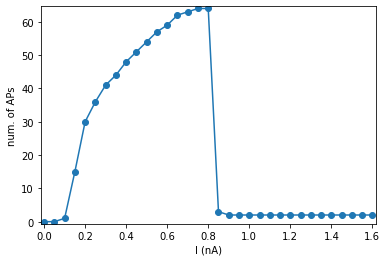

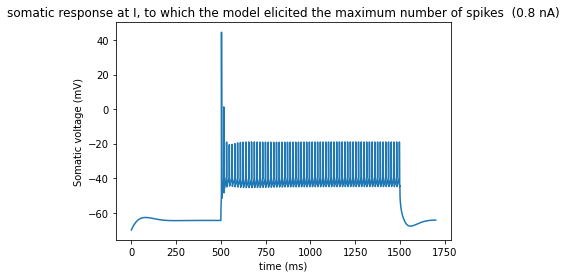

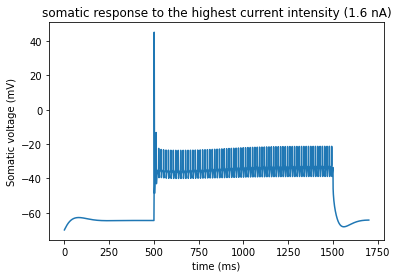

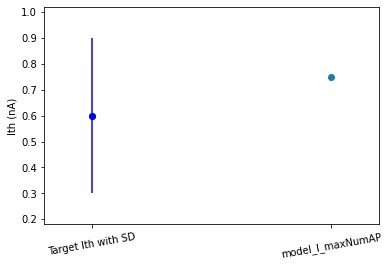

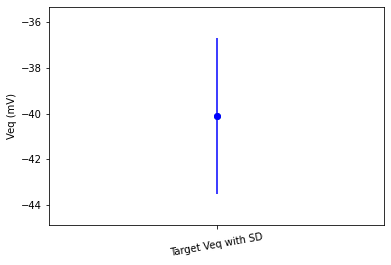

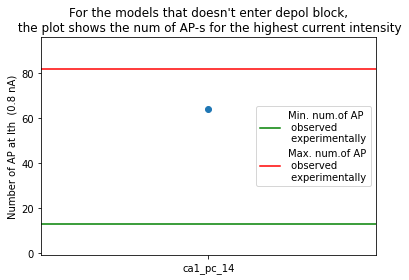

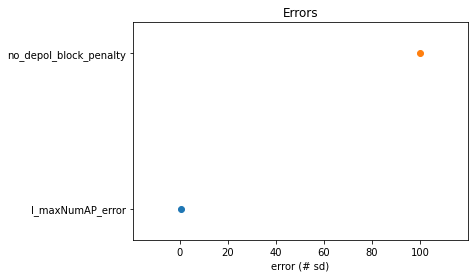

The model did not enter depolarization block.
[-47.7233744163709, 0.011401720134011, 0.17866165872572, 0.110533546361937, 0.018195328014435, 4.13376819751696e-06, 0.558280689990683, -55.1977064419009, 0.000102007454842, 2.35151579716906, 0.00018773285843, 0.008177991377281, 0.082608363126436, 3.69975735209366, 0.0, 3.69310750687799, 5.1266274824495e-05, 1.15317561526235e-05, -25.8009959332103, 9.72470557972213, 9.75671751943343]
- running amplitude: 0.05 on model: ca1_pc_15 at: soma(0.5)
- running amplitude: 0.6000000000000001 on model: ca1_pc_15 at: soma(0.5)- running amplitude: 0.4 on model: ca1_pc_15 at: soma(0.5)

- running amplitude: 0.9 on model: ca1_pc_15 at: soma(0.5)
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
- running amplitude: 0.30000000000000004 on model: ca1_pc_15 at: soma(0.5)- running amplitude: 

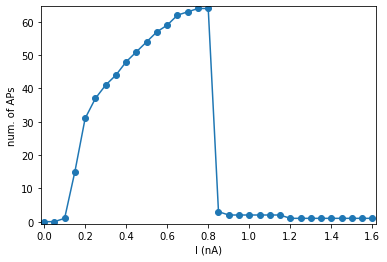

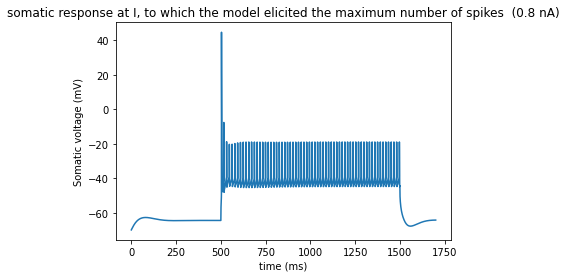

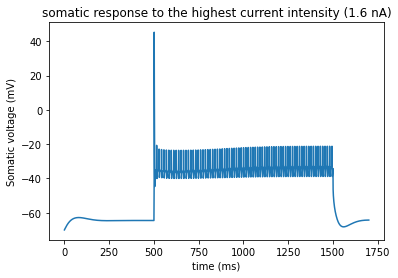

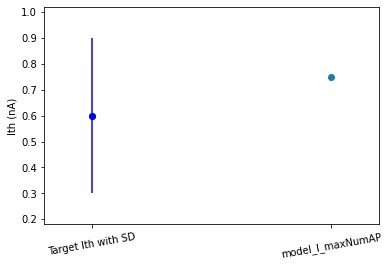

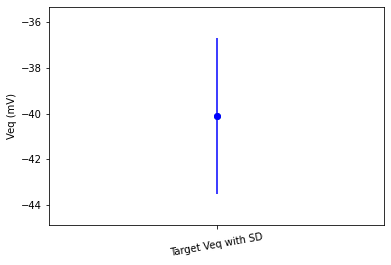

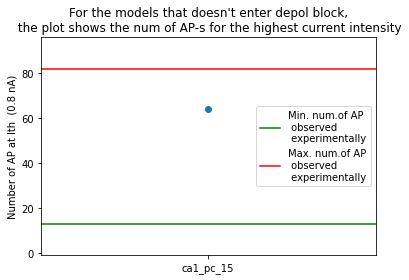

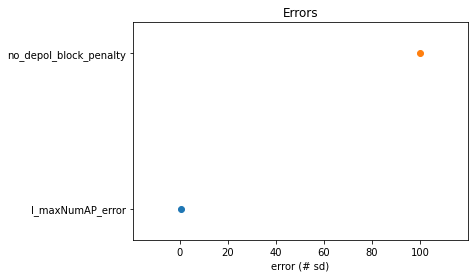

The model did not enter depolarization block.
[-47.7233744163709, 0.011401720134011, 0.17866165872572, 0.110533546361937, 0.018195328014435, 4.13376819751696e-06, 0.558280689990683, -55.1977064419009, 0.000102007454842, 2.35151579716906, 0.00018773285843, 0.008177991377281, 0.082608363126436, 3.69975735209366, 0.00058114570326, 0.0, 5.1266274824495e-05, 1.15317561526235e-05, -25.8009959332103, 9.72470557972213, 9.75671751943343]
- running amplitude: 0.5 on model: ca1_pc_16 at: soma(0.5)
- running amplitude: 0.2 on model: ca1_pc_16 at: soma(0.5)
- running amplitude: 0.7000000000000001 on model: ca1_pc_16 at: soma(0.5)
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
- running amplitude: 0.25 on model: ca1_pc_16 at: soma(0.5)- running amplitude: 0.05 on model: ca1_pc_16 at: soma(0.5)

- running amplitude: 0.0 on model: 

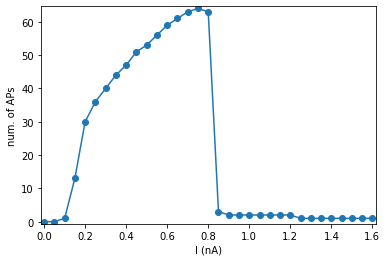

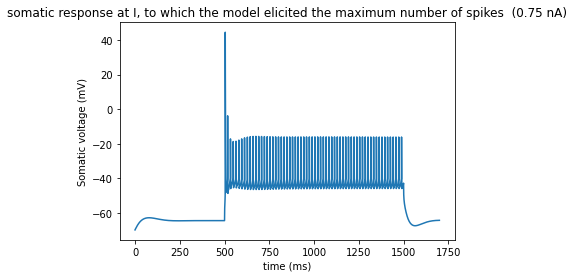

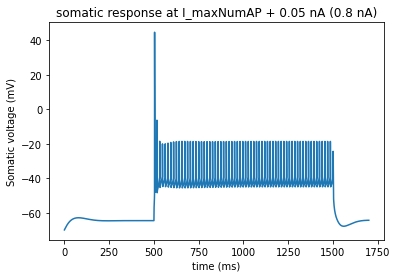

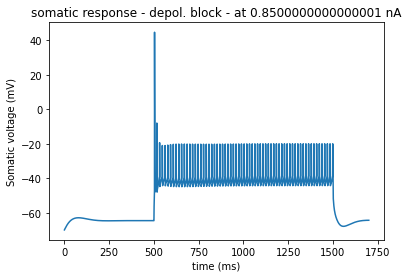

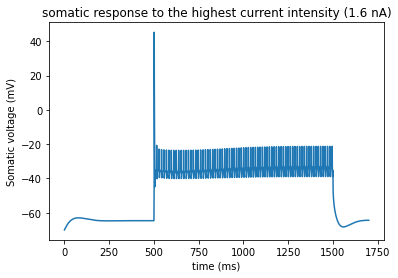

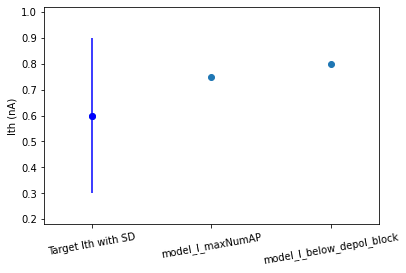

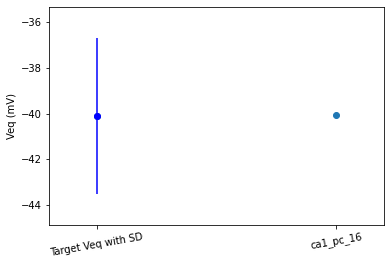

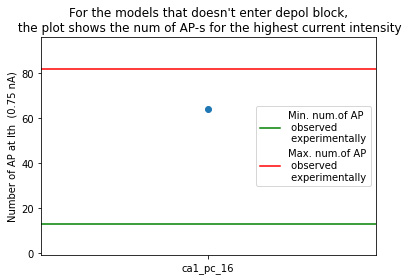

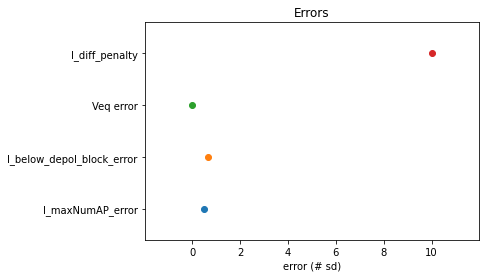

[-47.7233744163709, 0.011401720134011, 0.17866165872572, 0.110533546361937, 0.018195328014435, 4.13376819751696e-06, 0.558280689990683, -55.1977064419009, 0.000102007454842, 2.35151579716906, 0.00018773285843, 0.008177991377281, 0.082608363126436, 3.69975735209366, 0.00058114570326, 3.69310750687799, 0.0, 1.15317561526235e-05, -25.8009959332103, 9.72470557972213, 9.75671751943343]
- running amplitude: 0.8 on model: ca1_pc_17 at: soma(0.5)
- running amplitude: 0.55 on model: ca1_pc_17 at: soma(0.5)
- running amplitude: 0.2 on model: ca1_pc_17 at: soma(0.5)
- running amplitude: 0.65 on model: ca1_pc_17 at: soma(0.5)
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
- running amplitude: 0.30000000000000004 on model: ca1_pc_17 at: soma(0.5)- running amplitude: 0.4 on model: ca1_pc_17 at: soma(0.5)- running amplitude: 0.150

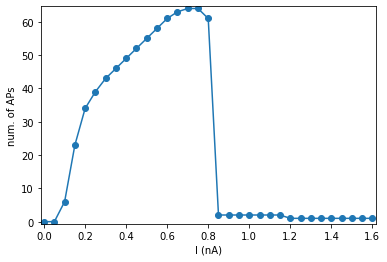

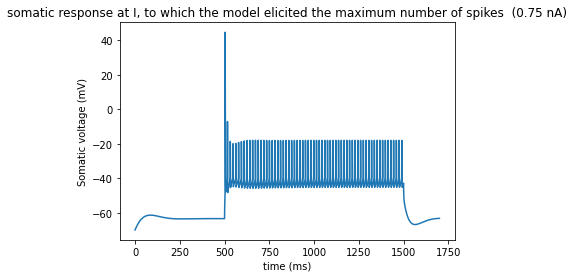

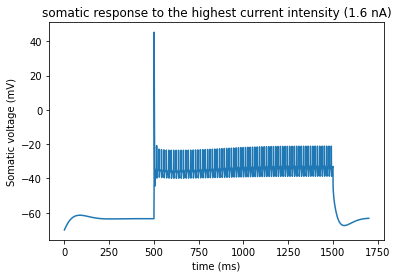

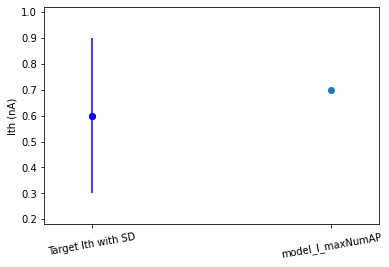

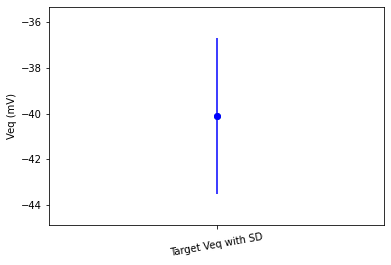

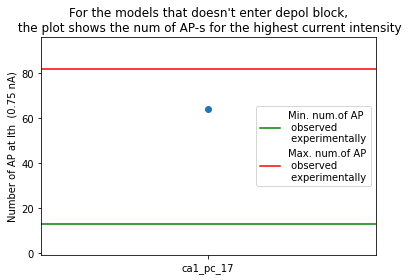

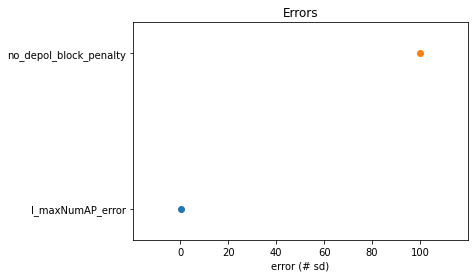

The model did not enter depolarization block.
[-47.7233744163709, 0.011401720134011, 0.17866165872572, 0.110533546361937, 0.018195328014435, 4.13376819751696e-06, 0.558280689990683, -55.1977064419009, 0.000102007454842, 2.35151579716906, 0.00018773285843, 0.008177991377281, 0.082608363126436, 3.69975735209366, 0.00058114570326, 3.69310750687799, 5.1266274824495e-05, 0.0, -25.8009959332103, 9.72470557972213, 9.75671751943343]
- running amplitude: 0.35000000000000003 on model: ca1_pc_18 at: soma(0.5)- running amplitude: 0.9 on model: ca1_pc_18 at: soma(0.5)

- running amplitude: 0.2 on model: ca1_pc_18 at: soma(0.5)
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
numprocs=1
- running amplitude: 0.45 on model: ca1_pc_18 at: soma(0.5)
- running amplitude: 0.4 on model: ca1_pc_18 at: soma(0.5)
- running amplitude: 0.3000000000000000

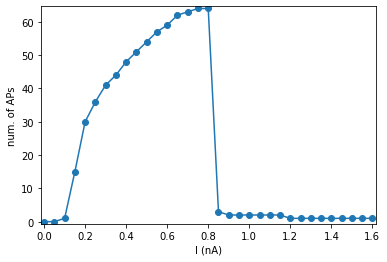

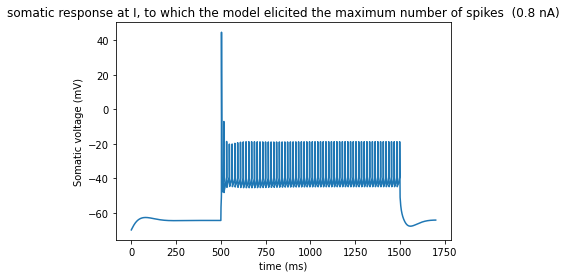

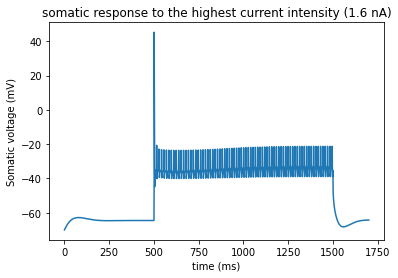

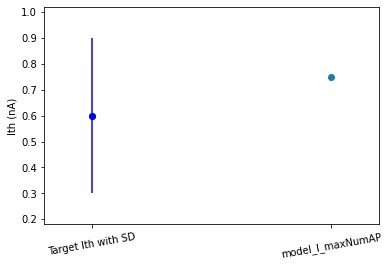

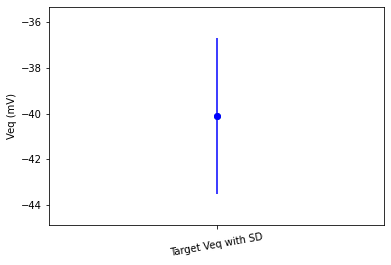

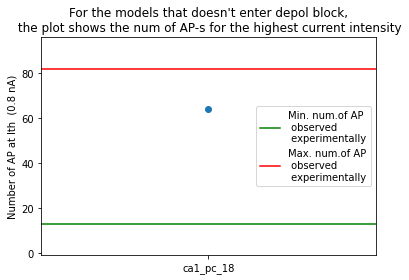

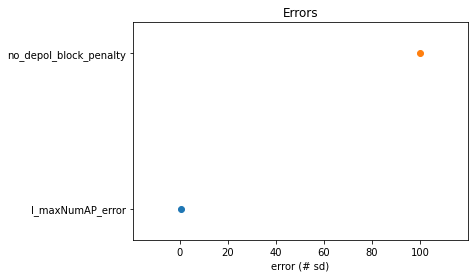

The model did not enter depolarization block.


In [9]:
# Instantiate the test class
test = tests.DepolarizationBlockTest(observation=observation, force_run=True, show_plot=True, save_all=True, base_directory=base_directory)

# Number of parallel processes
test.npool = 20

"""Edit the line below"""
f = open('/home/tarluca/Modellke_story/Luca_modell_rework_2/prep_and_run_model_rework_new_K_stuff/nsg_csomag_model_rework_new/results_ca1_results/last_13_blocking.csv')
lines = []
for l in f.readlines():
    #print l.strip().split(',')
    lines.append(l.strip().split(','))
f.close()

for i in range(1, len(lines)):
    parameters = [float(j) for j in lines[i]]
    #lines[i].pop(0)
    parameters.pop(0)
    print(parameters)
    
    model.parameters = parameters
    # outputs will be saved in folders named like this:
    """Edit the line below"""
    model.name="ca1_pc_"+str(i)
    if numpy.isnan(parameters[0]):
        print('Parameters are nan')
        pass
    else:
        try:
            #Run the test 
            score = test.judge(model)
            #Summarize and print the score achieved by the model on the test using SciUnit's summarize function
            score.summarize()

        except Exception as e:
            print('Model: ' + model.name + ' could not be run')
            print(e)
            pass
